In [46]:
import pandas as pd
import numpy as np
import os

data_dir = "./bda2025_mid_dataset/"
# data_dir = "/content/drive/MyDrive/Colab Notebooks/bda2025_mid_dataset/"


files = os.listdir(data_dir)
print("View all datasets:")
for f in files:
    print(f)

View all datasets:
bda2025_202301-202503_討論數據_dcard_1.csv
bda2025_202301-202503_討論數據_mobile01.csv
bda2025_202301-202503_內容數據_新聞.csv
bda2025_stock_202301-202503_上櫃.xlsx
bda2025_202301-202503_討論數據_dcard_2.csv
bda2025_stock_202301-202503_上市.xlsx
bda2025_202301-202503_討論數據_ptt.csv


In [47]:
# 設定 random seed
np.random.seed(69)

# 預測聯發科
Predicted_stock = "上揚"

def load_df(filepath, preview=True):
    print(f"\n----- Loading {filepath}... -----")
    df = pd.read_csv(data_dir + filepath)
    print(f"Size of dataframe: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    if preview:
        print(df.head())
    return df

import pandas as pd
import numpy as np

# 設定 random seed
np.random.seed(69)

# 預測聯發科
Predicted_stock = "上揚"

# 資料目錄
data_dir = "./"  # 根據實際情況修改你的資料夾路徑

def load_df_xlsx(filepath, preview=True):
    print(f"\n----- Loading {filepath}... -----")
    df = pd.read_excel(data_dir + filepath)  # 改成 read_excel
    print(f"Size of dataframe: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    if preview:
        print(df.head())
    return df

In [54]:

# transaction_df = load_df("bda2024_微股力_個股交易數據-2年.csv")
transaction_df_news = load_df("./bda2025_mid_dataset/bda2025_202301-202503_內容數據_新聞.csv")
transaction_df_dcard_1 = load_df("./bda2025_mid_dataset/bda2025_202301-202503_討論數據_dcard_1.csv")
transaction_df_dcard_2 = load_df("./bda2025_mid_dataset/bda2025_202301-202503_討論數據_dcard_2.csv")
transaction_df_mobile01 = load_df("./bda2025_mid_dataset/bda2025_202301-202503_討論數據_mobile01.csv")
transaction_df_ptt = load_df("./bda2025_mid_dataset/bda2025_202301-202503_討論數據_ptt.csv")

# shangyang_transaction_df = transaction_df.loc[transaction_df['stock_name'] == ""]
# print(shangyang_transaction_df.head())


----- Loading ./bda2025_mid_dataset/bda2025_202301-202503_內容數據_新聞.csv... -----
Size of dataframe: (558626, 9)
Columns: ['id', 'p_type', 's_name', 's_area_name', 'post_time', 'title', 'author', 'content', 'page_url']
                        id p_type   s_name s_area_name            post_time  \
0  1672541649216_YahooNews   news  Yahoo新聞        股市匯市  2023-01-01 10:45:18   
1  1672546740027_YahooNews   news  Yahoo新聞        股市匯市  2023-01-01 12:12:25   
2  1672564766561_YahooNews   news  Yahoo新聞        股市匯市  2023-01-01 17:11:26   
3  1672567021802_YahooNews   news  Yahoo新聞        股市匯市  2023-01-01 17:44:07   
4  1672567849204_YahooNews   news  Yahoo新聞        股市匯市  2023-01-01 18:01:02   

                        title author  \
0    年關將近！準備換新鈔 央行「鈔前部署」3招辨真假  三立新聞網   
1  快加油！油價明調漲 汽油貴0.4元、柴油調降0.1元    王馨儀   
2         2023台股展望！農曆年還有紅包行情？  民視新聞網   
3       「反生命」喊話楊文科 要求終止生命園區開發  民視新聞網   
4         2023台股展望！農曆年還有紅包行情？    NaN   

                                             content  \
0  記者戴玉翔／綜合

In [48]:
transaction_df_coun = load_df_xlsx("./bda2025_mid_dataset/bda2025_stock_202301-202503_上櫃.xlsx")
# transaction_df_list = load_df_xlsx("bda2025_stock_202301-202503_上市.xlsx")
transaction_df_coun


----- Loading ./bda2025_mid_dataset/bda2025_stock_202301-202503_上櫃.xlsx... -----
Size of dataframe: (258025, 36)
Columns: ['代號', '名稱', '年月日', '開盤價(元)', '最高價(元)', '最低價(元)', '收盤價(元)', '成交量(千股)', '成交值(千元)', '報酬率％', '週轉率％', '流通在外股數(千股)', '市值(百萬元)', '最後揭示買價', '最後揭示賣價', '報酬率-Ln', '市值比重％', '成交值比重％', '成交筆數(筆)', '本益比-TSE', '本益比-TEJ', '股價淨值比-TSE', '股價淨值比-TEJ', '漲跌停', '股價營收比-TEJ', '股利殖利率-TSE', '現金股利率', '股價漲跌(元)', '高低價差%', '次日開盤參考價', '次日漲停價', '次日跌停價', '注意股票(A)', '處置股票(D)', '全額交割(Y)', '市場別']
       代號        名稱         年月日   開盤價(元)   最高價(元)   最低價(元)   收盤價(元)  成交量(千股)  \
0  006201    元大富櫃50  2023/12/29  19.3811  19.3811  19.3134  19.3521      124   
1  00679B   元大美債20年  2023/12/29  29.1721  29.2478  29.1626  29.2100    24658   
2  00687B   國泰20年美債  2023/12/29  29.9876  30.0065  29.9593  30.0065    41231   
3  00694B   富邦美債1-3  2023/12/29  38.1862  38.2446  38.1279  38.2446      172   
4  00695B  富邦美債7-10  2023/12/29  33.5387  33.5871  33.5387  33.5871      107   

   成交值(千元)    報酬率％  ...   現金股利率  股

,代號,名稱,年月日,開盤價(元),最高價(元),最低價(元),收盤價(元),成交量(千股),成交值(千元),報酬率％,...,現金股利率,股價漲跌(元),高低價差%,次日開盤參考價,次日漲停價,次日跌停價,注意股票(A),處置股票(D),全額交割(Y),市場別
0,006201,元大富櫃50,2023/12/29,19.3811,19.3811,19.3134,19.3521,124,2490,-0.1498,...,3.2500,-0.03,0.3495,20.00,22.0,18.0,NaN,NaN,NaN,OTC
1,00679B,元大美債20年,2023/12/29,29.1721,29.2478,29.1626,29.2100,24658,760717,-0.1941,...,3.7601,-0.06,0.2912,30.85,NaN,NaN,NaN,NaN,NaN,OTC
2,00687B,國泰20年美債,2023/12/29,29.9876,30.0065,29.9593,30.0065,41231,1310558,-0.2196,...,3.9846,-0.07,0.1568,31.81,NaN,NaN,NaN,NaN,NaN,OTC
3,00694B,富邦美債1-3,2023/12/29,38.1862,38.2446,38.1279,38.2446,172,6760,0.4854,...,1.9235,0.19,0.3066,39.33,NaN,NaN,NaN,NaN,NaN,OTC
4,00695B,富邦美債7-10,2023/12/29,33.5387,33.5871,33.5387,33.5871,107,3729,0.2311,...,1.5144,0.08,0.1444,34.70,NaN,NaN,NaN,NaN,NaN,OTC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258020,TPCGR,櫃 CG TR,2023/01/03,NaN,NaN,NaN,200.3700,94430,12257157,2.3445,...,4.4408,4.59,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,OTC
258021,TPCI,櫃買薪酬,2023/01/03,NaN,NaN,NaN,96.3100,119234,17392846,1.9261,...,3.9498,1.82,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,OTC
258022,TPCIR,櫃薪TR,2023/01/03,NaN,NaN,NaN,127.8600,119234,17392846,1.9292,...,3.9498,2.42,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,OTC
258023,Z50TR,富櫃50報酬指數,2023/01/03,NaN,NaN,NaN,308.5400,121660,19847290,2.3622,...,4.5063,7.12,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,OTC


In [49]:
transaction_df_coun.head()
# transaction_df_list 


,代號,名稱,年月日,開盤價(元),最高價(元),最低價(元),收盤價(元),成交量(千股),成交值(千元),報酬率％,...,現金股利率,股價漲跌(元),高低價差%,次日開盤參考價,次日漲停價,次日跌停價,注意股票(A),處置股票(D),全額交割(Y),市場別
0,006201,元大富櫃50,2023/12/29,19.3811,19.3811,19.3134,19.3521,124,2490,-0.1498,...,3.2500,-0.03,0.3495,20.00,22.0,18.0,NaN,NaN,NaN,OTC
1,00679B,元大美債20年,2023/12/29,29.1721,29.2478,29.1626,29.2100,24658,760717,-0.1941,...,3.7601,-0.06,0.2912,30.85,NaN,NaN,NaN,NaN,NaN,OTC
2,00687B,國泰20年美債,2023/12/29,29.9876,30.0065,29.9593,30.0065,41231,1310558,-0.2196,...,3.9846,-0.07,0.1568,31.81,NaN,NaN,NaN,NaN,NaN,OTC
3,00694B,富邦美債1-3,2023/12/29,38.1862,38.2446,38.1279,38.2446,172,6760,0.4854,...,1.9235,0.19,0.3066,39.33,NaN,NaN,NaN,NaN,NaN,OTC
4,00695B,富邦美債7-10,2023/12/29,33.5387,33.5871,33.5387,33.5871,107,3729,0.2311,...,1.5144,0.08,0.1444,34.70,NaN,NaN,NaN,NaN,NaN,OTC


transaction_df_mobile01




In [50]:
len(set(transaction_df_coun["名稱"]))
names_coun = set(transaction_df_coun["名稱"])

In [ ]:
# transaction_df_news
# transaction_df_dcard_1
# transaction_df_dcard_2
# transaction_df_mobile01
# transaction_df_ptt

### 討論文章

In [51]:
shangyang_transaction_df = transaction_df_coun.loc[transaction_df_coun['名稱'] == "上揚"]

In [55]:
sources = [
    transaction_df_news,
    transaction_df_dcard_1,
    transaction_df_dcard_2,
    transaction_df_mobile01,
    transaction_df_ptt
]



In [56]:
import pandas as pd

# 合併所有新聞 df
news_df = pd.concat(sources, ignore_index=True)
news_df.head()

,id,p_type,s_name,s_area_name,post_time,title,author,content,page_url,content_type
0,1672541649216_YahooNews,news,Yahoo新聞,股市匯市,2023-01-01 10:45:18,年關將近！準備換新鈔 央行「鈔前部署」3招辨真假,三立新聞網,記者戴玉翔／綜合報導新的一年即將到來，而在農曆年前，台灣人都有換新鈔的習慣，中央銀行預計會在...,https://tw.news.yahoo.com/%E5%B9%B4%E9%97%9C%E...,NaN
1,1672546740027_YahooNews,news,Yahoo新聞,股市匯市,2023-01-01 12:12:25,快加油！油價明調漲 汽油貴0.4元、柴油調降0.1元,王馨儀,台灣中油公司自明（2）日凌晨零時起汽油調漲0.4元、柴油調降0.1元，參考零售價格分別為92...,https://tw.news.yahoo.com/%E5%BF%AB%E5%8A%A0%E...,NaN
2,1672564766561_YahooNews,news,Yahoo新聞,股市匯市,2023-01-01 17:11:26,2023台股展望！農曆年還有紅包行情？,民視新聞網,民視新聞／綜合報導台北股市已經在2022年經歷過大熊市，那麼在即將到來的2023年，有沒有機...,https://tw.news.yahoo.com/2023%E5%8F%B0%E8%82%...,NaN
3,1672567021802_YahooNews,news,Yahoo新聞,股市匯市,2023-01-01 17:44:07,「反生命」喊話楊文科 要求終止生命園區開發,民視新聞網,民視新聞／ 綜合報導新竹縣的元旦升旗典禮，發生場外插曲，原來是新豐、湖口兩鄉居民，組成的反生...,https://tw.news.yahoo.com/%E5%8F%8D%E7%94%9F%E...,NaN
4,1672567849204_YahooNews,news,Yahoo新聞,股市匯市,2023-01-01 18:01:02,2023台股展望！農曆年還有紅包行情？,NaN,民視新聞／綜合報導台北股市已經在2022年經歷過大熊市，那麼在即將到來的2023年，有沒有機...,https://tw.news.yahoo.com/2023%E5%8F%B0%E8%82%...,NaN


In [106]:
# 合併所有新聞 df
news_df = pd.concat(sources, ignore_index=True)

# 假設有個欄位叫做 '年月日'（日期格式），我們把它轉成 datetime
news_df['post_time'] = pd.to_datetime(news_df['post_time'])

Sorted_shangyang_transaction_df = shangyang_transaction_df.sort_values(by='年月日', ignore_index=True)
Sorted_shangyang_transaction_df['收盤價(元)'] = Sorted_shangyang_transaction_df['收盤價(元)'].astype(float)

Sorted_shangyang_transaction_df['年月日'] = pd.to_datetime(Sorted_shangyang_transaction_df['年月日'])
Sorted_shangyang_transaction_df['next_day_return'] = Sorted_shangyang_transaction_df['報酬率％'].shift(-1)

In [58]:
# shangyang_transaction_df = shangyang_transaction_df.rename(columns={'年月日': 'post_time'})
Sorted_shangyang_transaction_df.head()

,代號,名稱,年月日,開盤價(元),最高價(元),最低價(元),收盤價(元),成交量(千股),成交值(千元),報酬率％,...,股價漲跌(元),高低價差%,次日開盤參考價,次日漲停價,次日跌停價,注意股票(A),處置股票(D),全額交割(Y),市場別,next_day_return
0,6222,上揚,2023-01-03,14.65,14.65,14.65,14.65,0,12,0.0000,...,0.00,0.0000,14.65,16.10,13.20,NaN,NaN,NaN,OTC,0.0000
1,6222,上揚,2023-01-04,14.65,14.65,14.65,14.65,0,0,0.0000,...,0.00,0.0000,14.65,16.10,13.20,NaN,NaN,NaN,OTC,2.7304
2,6222,上揚,2023-01-05,15.05,15.05,15.05,15.05,3,45,2.7304,...,0.40,0.0000,15.05,16.55,13.55,NaN,NaN,NaN,OTC,0.6645
3,6222,上揚,2023-01-06,15.10,15.15,15.10,15.15,3,45,0.6645,...,0.10,0.3322,15.15,16.65,13.65,NaN,NaN,NaN,OTC,-2.3102
4,6222,上揚,2023-01-09,14.85,14.85,14.80,14.80,4,59,-2.3102,...,-0.35,0.3300,14.80,16.25,13.35,NaN,NaN,NaN,OTC,1.3514


In [59]:
news_df['post_time'] = pd.to_datetime(news_df['post_time'])
news_df['date_only'] = news_df['post_time'].dt.date

In [60]:
Sorted_shangyang_transaction_df['date_only'] = Sorted_shangyang_transaction_df['年月日'].dt.date
returns_df = Sorted_shangyang_transaction_df[['date_only', 'next_day_return']]
returns_df['date_only']

0      2023-01-03
1      2023-01-04
2      2023-01-05
3      2023-01-06
4      2023-01-09
          ...    
234    2023-12-25
235    2023-12-26
236    2023-12-27
237    2023-12-28
238    2023-12-29
Name: date_only, Length: 239, dtype: object

In [61]:
import datetime

news_df['date_only']
news_df = news_df[news_df['date_only'] <= datetime.date(2023, 12, 31)]

In [64]:
# 把新聞跟 return 合併
news_df_merged = pd.merge(news_df, returns_df, on='date_only', how='left')
news_df_merged.head()

,id,p_type,s_name,s_area_name,post_time,title,author,content,page_url,content_type,date_only,next_day_return
0,1672541649216_YahooNews,news,Yahoo新聞,股市匯市,2023-01-01 10:45:18,年關將近！準備換新鈔 央行「鈔前部署」3招辨真假,三立新聞網,記者戴玉翔／綜合報導新的一年即將到來，而在農曆年前，台灣人都有換新鈔的習慣，中央銀行預計會在...,https://tw.news.yahoo.com/%E5%B9%B4%E9%97%9C%E...,NaN,2023-01-01,NaN
1,1672546740027_YahooNews,news,Yahoo新聞,股市匯市,2023-01-01 12:12:25,快加油！油價明調漲 汽油貴0.4元、柴油調降0.1元,王馨儀,台灣中油公司自明（2）日凌晨零時起汽油調漲0.4元、柴油調降0.1元，參考零售價格分別為92...,https://tw.news.yahoo.com/%E5%BF%AB%E5%8A%A0%E...,NaN,2023-01-01,NaN
2,1672564766561_YahooNews,news,Yahoo新聞,股市匯市,2023-01-01 17:11:26,2023台股展望！農曆年還有紅包行情？,民視新聞網,民視新聞／綜合報導台北股市已經在2022年經歷過大熊市，那麼在即將到來的2023年，有沒有機...,https://tw.news.yahoo.com/2023%E5%8F%B0%E8%82%...,NaN,2023-01-01,NaN
3,1672567021802_YahooNews,news,Yahoo新聞,股市匯市,2023-01-01 17:44:07,「反生命」喊話楊文科 要求終止生命園區開發,民視新聞網,民視新聞／ 綜合報導新竹縣的元旦升旗典禮，發生場外插曲，原來是新豐、湖口兩鄉居民，組成的反生...,https://tw.news.yahoo.com/%E5%8F%8D%E7%94%9F%E...,NaN,2023-01-01,NaN
4,1672567849204_YahooNews,news,Yahoo新聞,股市匯市,2023-01-01 18:01:02,2023台股展望！農曆年還有紅包行情？,NaN,民視新聞／綜合報導台北股市已經在2022年經歷過大熊市，那麼在即將到來的2023年，有沒有機...,https://tw.news.yahoo.com/2023%E5%8F%B0%E8%82%...,NaN,2023-01-01,NaN


In [17]:
news_df_merged['next_day_return']

0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
          ..
286796   NaN
286797   NaN
286798   NaN
286799   NaN
286800   NaN
Name: next_day_return, Length: 286801, dtype: float64

In [18]:
news_df_merged['next_day_return'] = news_df_merged['next_day_return'].fillna(method='bfill')

/var/folders/f3/9y7tdbks435ff8n7qys30_n80000gn/T/ipykernel_1795/1995443699.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  news_df_merged['next_day_return'] = news_df_merged['next_day_return'].fillna(method='bfill')


In [19]:
news_df_merged.head()

,id,p_type,s_name,s_area_name,post_time,title,author,content,page_url,content_type,date_only,next_day_return
0,1672541649216_YahooNews,news,Yahoo新聞,股市匯市,2023-01-01 10:45:18,年關將近！準備換新鈔 央行「鈔前部署」3招辨真假,三立新聞網,記者戴玉翔／綜合報導新的一年即將到來，而在農曆年前，台灣人都有換新鈔的習慣，中央銀行預計會在...,https://tw.news.yahoo.com/%E5%B9%B4%E9%97%9C%E...,NaN,2023-01-01,0.0
1,1672546740027_YahooNews,news,Yahoo新聞,股市匯市,2023-01-01 12:12:25,快加油！油價明調漲 汽油貴0.4元、柴油調降0.1元,王馨儀,台灣中油公司自明（2）日凌晨零時起汽油調漲0.4元、柴油調降0.1元，參考零售價格分別為92...,https://tw.news.yahoo.com/%E5%BF%AB%E5%8A%A0%E...,NaN,2023-01-01,0.0
2,1672564766561_YahooNews,news,Yahoo新聞,股市匯市,2023-01-01 17:11:26,2023台股展望！農曆年還有紅包行情？,民視新聞網,民視新聞／綜合報導台北股市已經在2022年經歷過大熊市，那麼在即將到來的2023年，有沒有機...,https://tw.news.yahoo.com/2023%E5%8F%B0%E8%82%...,NaN,2023-01-01,0.0
3,1672567021802_YahooNews,news,Yahoo新聞,股市匯市,2023-01-01 17:44:07,「反生命」喊話楊文科 要求終止生命園區開發,民視新聞網,民視新聞／ 綜合報導新竹縣的元旦升旗典禮，發生場外插曲，原來是新豐、湖口兩鄉居民，組成的反生...,https://tw.news.yahoo.com/%E5%8F%8D%E7%94%9F%E...,NaN,2023-01-01,0.0
4,1672567849204_YahooNews,news,Yahoo新聞,股市匯市,2023-01-01 18:01:02,2023台股展望！農曆年還有紅包行情？,NaN,民視新聞／綜合報導台北股市已經在2022年經歷過大熊市，那麼在即將到來的2023年，有沒有機...,https://tw.news.yahoo.com/2023%E5%8F%B0%E8%82%...,NaN,2023-01-01,0.0


In [20]:
news_df_merged['next_day_return']

0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
286796    NaN
286797    NaN
286798    NaN
286799    NaN
286800    NaN
Name: next_day_return, Length: 286801, dtype: float64

In [21]:
news_df_merged

,id,p_type,s_name,s_area_name,post_time,title,author,content,page_url,content_type,date_only,next_day_return
0,1672541649216_YahooNews,news,Yahoo新聞,股市匯市,2023-01-01 10:45:18,年關將近！準備換新鈔 央行「鈔前部署」3招辨真假,三立新聞網,記者戴玉翔／綜合報導新的一年即將到來，而在農曆年前，台灣人都有換新鈔的習慣，中央銀行預計會在...,https://tw.news.yahoo.com/%E5%B9%B4%E9%97%9C%E...,NaN,2023-01-01,0.0
1,1672546740027_YahooNews,news,Yahoo新聞,股市匯市,2023-01-01 12:12:25,快加油！油價明調漲 汽油貴0.4元、柴油調降0.1元,王馨儀,台灣中油公司自明（2）日凌晨零時起汽油調漲0.4元、柴油調降0.1元，參考零售價格分別為92...,https://tw.news.yahoo.com/%E5%BF%AB%E5%8A%A0%E...,NaN,2023-01-01,0.0
2,1672564766561_YahooNews,news,Yahoo新聞,股市匯市,2023-01-01 17:11:26,2023台股展望！農曆年還有紅包行情？,民視新聞網,民視新聞／綜合報導台北股市已經在2022年經歷過大熊市，那麼在即將到來的2023年，有沒有機...,https://tw.news.yahoo.com/2023%E5%8F%B0%E8%82%...,NaN,2023-01-01,0.0
3,1672567021802_YahooNews,news,Yahoo新聞,股市匯市,2023-01-01 17:44:07,「反生命」喊話楊文科 要求終止生命園區開發,民視新聞網,民視新聞／ 綜合報導新竹縣的元旦升旗典禮，發生場外插曲，原來是新豐、湖口兩鄉居民，組成的反生...,https://tw.news.yahoo.com/%E5%8F%8D%E7%94%9F%E...,NaN,2023-01-01,0.0
4,1672567849204_YahooNews,news,Yahoo新聞,股市匯市,2023-01-01 18:01:02,2023台股展望！農曆年還有紅包行情？,NaN,民視新聞／綜合報導台北股市已經在2022年經歷過大熊市，那麼在即將到來的2023年，有沒有機...,https://tw.news.yahoo.com/2023%E5%8F%B0%E8%82%...,NaN,2023-01-01,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
286796,1704029253846_PTT02R,bbs,Ptt,Stock,2023-12-31 21:25:05,Re: [新聞] 2024年AI PC全面引爆!謝金河揭緯創等3檔接,Tox,IDC 2023 Q3 PC https://i.imgur.com/VtPXIeT.png...,http://www.ptt.cc/bbs/Stock/M.1704029109.A.BED...,NaN,2023-12-31,NaN
286797,1704029391834_PTT02R,bbs,Ptt,Stock,2023-12-31 21:28:28,[心得] 本保羅2023年的操作回顧及經驗分享,Paul1021,各位股板的板友大家好喔 是這樣子的 保羅要跟大家分享2023年保羅的操作回顧 以及經驗...,http://www.ptt.cc/bbs/Stock/M.1704029310.A.4D6...,NaN,2023-12-31,NaN
286798,1704033954867_PTT02R,bbs,Ptt,Stock,2023-12-31 22:44:23,2023年年報,athlon3200,先上圖，證券只能查半年損益 https://i.imgur.com/n4bCvtG.jpg ...,http://www.ptt.cc/bbs/Stock/M.1704033865.A.9BB...,NaN,2023-12-31,NaN
286799,1704035621409_PTT02R,bbs,Ptt,Stock,2023-12-31 23:11:37,[請益] 台灣晶圓代工的強項,greedyba,我在鑽研台灣晶圓代工概念股的優劣勢 台灣晶圓代工在全世界排第一梯次 可是晶圓代工需要的化學原...,http://www.ptt.cc/bbs/Stock/M.1704035500.A.72E...,NaN,2023-12-31,NaN


##### 計算標準差

In [22]:
shangyang_transaction_df

,代號,名稱,年月日,開盤價(元),最高價(元),最低價(元),收盤價(元),成交量(千股),成交值(千元),報酬率％,...,現金股利率,股價漲跌(元),高低價差%,次日開盤參考價,次日漲停價,次日跌停價,注意股票(A),處置股票(D),全額交割(Y),市場別
755,6222,上揚,2023/12/29,33.10,33.70,32.50,32.50,143,4757,-1.8127,...,0.0,-0.60,3.6254,32.50,35.75,29.25,A,NaN,NaN,OTC
1902,6222,上揚,2023/12/28,33.15,33.70,32.25,33.10,313,10431,-4.8851,...,0.0,-1.70,4.1667,33.10,36.40,29.80,A,NaN,NaN,OTC
3049,6222,上揚,2023/12/27,31.80,36.30,31.35,34.80,770,24916,0.0000,...,0.0,0.00,14.2241,34.80,38.25,31.35,NaN,NaN,NaN,OTC
4196,6222,上揚,2023/12/26,34.80,35.90,34.80,34.80,501,17488,-9.9612,...,0.0,-3.85,2.8461,34.80,38.25,31.35,NaN,NaN,NaN,OTC
5343,6222,上揚,2023/12/25,40.05,41.20,38.65,38.65,639,25294,-9.9068,...,0.0,-4.25,5.9441,38.65,42.50,34.80,NaN,D,NaN,OTC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253532,6222,上揚,2023/01/09,14.85,14.85,14.80,14.80,4,59,-2.3102,...,0.0,-0.35,0.3300,14.80,16.25,13.35,NaN,NaN,NaN,OTC
254569,6222,上揚,2023/01/06,15.10,15.15,15.10,15.15,3,45,0.6645,...,0.0,0.10,0.3322,15.15,16.65,13.65,NaN,NaN,NaN,OTC
255606,6222,上揚,2023/01/05,15.05,15.05,15.05,15.05,3,45,2.7304,...,0.0,0.40,0.0000,15.05,16.55,13.55,NaN,NaN,NaN,OTC
256643,6222,上揚,2023/01/04,14.65,14.65,14.65,14.65,0,0,0.0000,...,0.0,0.00,0.0000,14.65,16.10,13.20,NaN,NaN,NaN,OTC


In [105]:
import pandas as pd
from scipy.stats import norm


# 計算Return的平均值和標準差
mean_return = shangyang_transaction_df['報酬率％'].mean()
std_return = shangyang_transaction_df['報酬率％'].std()

# 設定信賴水準alpha 0.01，對應 99% 的信賴區間
alpha = 0.05
z_score = norm.ppf(1 - alpha/2)

# 計算信賴區間 小於下界標記為-1 大於上界標記為1 落在區間內則標記為0
ci_lower = mean_return - z_score * (std_return / (len(shangyang_transaction_df['報酬率％'])**0.5)) - 0.01
ci_upper = mean_return + z_score * (std_return / (len(shangyang_transaction_df['報酬率％'])**0.5)) + 0.01

# # 更新Change列
shangyang_transaction_df['Change'] = shangyang_transaction_df['報酬率％'].apply(
    lambda x: -1 if x < ci_lower else (1 if x > ci_upper else 0)
)

# news_df_merged['Change'] = news_df_merged['next_day_return'].apply(
#     lambda x: -1 if x < ci_lower else (1 if x > ci_upper else 0)
# )

# 輸出更新後的DataFrame
print(shangyang_transaction_df[['報酬率％', 'Change']])
shangyang_transaction_df['年月日'] = pd.to_datetime(shangyang_transaction_df['年月日'])
shangyang_transaction_df['Previous_date'] = shangyang_transaction_df['年月日'] - pd.Timedelta(days = 1)

print(shangyang_transaction_df)


          報酬率％  Change
755    -1.8127      -1
1902   -4.8851      -1
3049    0.0000       0
4196   -9.9612      -1
5343   -9.9068      -1
...        ...     ...
253532 -2.3102      -1
254569  0.6645       0
255606  2.7304       1
256643  0.0000       0
257680  0.0000       0

[239 rows x 2 columns]
          代號  名稱        年月日  開盤價(元)  最高價(元)  最低價(元)  收盤價(元)  成交量(千股)  成交值(千元)  \
755     6222  上揚 2023-12-29   33.10   33.70   32.50   32.50      143     4757   
1902    6222  上揚 2023-12-28   33.15   33.70   32.25   33.10      313    10431   
3049    6222  上揚 2023-12-27   31.80   36.30   31.35   34.80      770    24916   
4196    6222  上揚 2023-12-26   34.80   35.90   34.80   34.80      501    17488   
5343    6222  上揚 2023-12-25   40.05   41.20   38.65   38.65      639    25294   
...      ...  ..        ...     ...     ...     ...     ...      ...      ...   
253532  6222  上揚 2023-01-09   14.85   14.85   14.80   14.80        4       59   
254569  6222  上揚 2023-01-06   15.10   15.15   15.10 

In [35]:
# 篩選出 tag 值為 1 和 -1 的資料，分別儲存
MTK_UP = shangyang_transaction_df[shangyang_transaction_df['Change'] == 1]
MTK_DOWN = shangyang_transaction_df[shangyang_transaction_df['Change'] == -1]

# 僅保留日期和tag欄位
MTK_UP = MTK_UP[['年月日', 'Previous_date', 'Change']]
MTK_DOWN = MTK_DOWN[['年月日', 'Previous_date', 'Change']]

# 將篩選後的結果儲存為新的檔案
MTK_UP.to_csv('MTK_UP.csv', index=False)
print(MTK_UP)  # [113 rows x 3 columns]
MTK_DOWN.to_csv('MTK_DOWN.csv', index=False)
print(MTK_DOWN)  # [116 rows x 3 columns]

              年月日 Previous_date  Change
9922   2023-12-19    2023-12-18       1
11066  2023-12-18    2023-12-17       1
12207  2023-12-15    2023-12-14       1
13347  2023-12-14    2023-12-13       1
17899  2023-12-08    2023-12-07       1
...           ...           ...     ...
228618 2023-02-22    2023-02-21       1
234849 2023-02-14    2023-02-13       1
247305 2023-01-17    2023-01-16       1
252495 2023-01-10    2023-01-09       1
255606 2023-01-05    2023-01-04       1

[75 rows x 3 columns]
              年月日 Previous_date  Change
755    2023-12-29    2023-12-28      -1
1902   2023-12-28    2023-12-27      -1
4196   2023-12-26    2023-12-25      -1
5343   2023-12-25    2023-12-24      -1
6488   2023-12-22    2023-12-21      -1
...           ...           ...     ...
236925 2023-02-10    2023-02-09      -1
240039 2023-02-07    2023-02-06      -1
248343 2023-01-16    2023-01-15      -1
251457 2023-01-11    2023-01-10      -1
253532 2023-01-09    2023-01-08      -1

[108 rows x 3 co

In [70]:
shangyang_transaction_df

,代號,名稱,年月日,開盤價(元),最高價(元),最低價(元),收盤價(元),成交量(千股),成交值(千元),報酬率％,...,高低價差%,次日開盤參考價,次日漲停價,次日跌停價,注意股票(A),處置股票(D),全額交割(Y),市場別,Change,Previous_date
755,6222,上揚,2023-12-29,33.10,33.70,32.50,32.50,143,4757,-1.8127,...,3.6254,32.50,35.75,29.25,A,NaN,NaN,OTC,-1,2023-12-28
1902,6222,上揚,2023-12-28,33.15,33.70,32.25,33.10,313,10431,-4.8851,...,4.1667,33.10,36.40,29.80,A,NaN,NaN,OTC,-1,2023-12-27
3049,6222,上揚,2023-12-27,31.80,36.30,31.35,34.80,770,24916,0.0000,...,14.2241,34.80,38.25,31.35,NaN,NaN,NaN,OTC,0,2023-12-26
4196,6222,上揚,2023-12-26,34.80,35.90,34.80,34.80,501,17488,-9.9612,...,2.8461,34.80,38.25,31.35,NaN,NaN,NaN,OTC,-1,2023-12-25
5343,6222,上揚,2023-12-25,40.05,41.20,38.65,38.65,639,25294,-9.9068,...,5.9441,38.65,42.50,34.80,NaN,D,NaN,OTC,-1,2023-12-24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253532,6222,上揚,2023-01-09,14.85,14.85,14.80,14.80,4,59,-2.3102,...,0.3300,14.80,16.25,13.35,NaN,NaN,NaN,OTC,-1,2023-01-08
254569,6222,上揚,2023-01-06,15.10,15.15,15.10,15.15,3,45,0.6645,...,0.3322,15.15,16.65,13.65,NaN,NaN,NaN,OTC,0,2023-01-05
255606,6222,上揚,2023-01-05,15.05,15.05,15.05,15.05,3,45,2.7304,...,0.0000,15.05,16.55,13.55,NaN,NaN,NaN,OTC,1,2023-01-04
256643,6222,上揚,2023-01-04,14.65,14.65,14.65,14.65,0,0,0.0000,...,0.0000,14.65,16.10,13.20,NaN,NaN,NaN,OTC,0,2023-01-03


In [37]:
# 使用關鍵字“上揚”篩選新聞
filtered_news = news_df[(news_df['title'].str.contains("上揚")) | (news_df['content'].str.contains("上揚"))]

# 保留需要的列並轉換post_time列為datetime格式
filtered_news = filtered_news[["post_time", "title", "content"]]
filtered_news['post_time'] = pd.to_datetime(filtered_news['post_time'])

# 顯示結果
print(filtered_news)

                 post_time                       title  \
69     2023-01-04 19:04:09           渣打估美年底降息 美元Q1見頂回落   
76     2023-01-05 04:10:00                美債殖利率飆升 銀行警戒   
84     2023-01-05 09:38:29            股匯齊揚 台幣早盤升破30.7元   
87     2023-01-05 11:08:09        台積電帶領半導體股勁揚 台股盤中漲逾百點   
103    2023-01-06 04:10:00              需求回溫 金像電、矽創權證夯   
...                    ...                         ...   
625492 2023-12-27 11:21:16              [心得] 年度績效與策略分享   
625501 2023-12-27 13:52:49   [新聞] 標普：美國房價指數創歷史新高、連續第9-   
625529 2023-12-27 19:18:45                        [新聞]   
625636 2023-12-29 12:51:09   [新聞] 萬八一定見 谷月涵拋台股4箭 謝金河按讚   
625713 2023-12-30 10:20:02  [新聞] 貨櫃運價火 一周暴漲40% 歐洲線狂飆八成   

                                                  content  
69      [NOWnews今日新聞]進入2023年，全球金融情勢依舊充滿許多不確定因子，包括疫情反覆、...  
76      2022全年美債殖利率一路飆升，銀行業者大敲警鐘，更主動進行壓力測試。根據金融圈人士透露，已...  
84      [NOWnews今日新聞]美國聯準會（Fed）公布2022年12月會議紀要，顯示聯準會官員仍...  
87      （中央社記者張建中台北5日電）美股收高，費城半導體指數勁揚逾2%。台股今天在台積電股價反彈，...  
103

In [68]:
# 使用關鍵字“上揚”篩選新聞
filtered_news_merged = news_df_merged[(news_df_merged['title'].str.contains("上揚")) | (news_df_merged['content'].str.contains("上揚"))]

filtered_news_merged['Change'] = filtered_news_merged['next_day_return'].apply(
    lambda x: -1 if x < ci_lower else (1 if x > ci_upper else 0)
)
filtered_news_merged
# news_df_merged 

# # 保留需要的列並轉換post_time列為datetime格式
filtered_news_merged = filtered_news_merged[["post_time", "title", "content", "Change"]]
filtered_news_merged['post_time'] = pd.to_datetime(filtered_news_merged['post_time'])

# 顯示結果
print(filtered_news_merged)

                 post_time                       title  \
69     2023-01-04 19:04:09           渣打估美年底降息 美元Q1見頂回落   
76     2023-01-05 04:10:00                美債殖利率飆升 銀行警戒   
84     2023-01-05 09:38:29            股匯齊揚 台幣早盤升破30.7元   
87     2023-01-05 11:08:09        台積電帶領半導體股勁揚 台股盤中漲逾百點   
103    2023-01-06 04:10:00              需求回溫 金像電、矽創權證夯   
...                    ...                         ...   
286521 2023-12-27 11:21:16              [心得] 年度績效與策略分享   
286530 2023-12-27 13:52:49   [新聞] 標普：美國房價指數創歷史新高、連續第9-   
286558 2023-12-27 19:18:45                        [新聞]   
286665 2023-12-29 12:51:09   [新聞] 萬八一定見 谷月涵拋台股4箭 謝金河按讚   
286742 2023-12-30 10:20:02  [新聞] 貨櫃運價火 一周暴漲40% 歐洲線狂飆八成   

                                                  content  Change  
69      [NOWnews今日新聞]進入2023年，全球金融情勢依舊充滿許多不確定因子，包括疫情反覆、...       1  
76      2022全年美債殖利率一路飆升，銀行業者大敲警鐘，更主動進行壓力測試。根據金融圈人士透露，已...       0  
84      [NOWnews今日新聞]美國聯準會（Fed）公布2022年12月會議紀要，顯示聯準會官員仍...       0  
87      （中央社記者張建中台北5日電）美股收高，費城半

In [ ]:
filtered_news.head()

,post_time,title,content
69,2023-01-04,渣打估美年底降息 美元Q1見頂回落,[NOWnews今日新聞]進入2023年，全球金融情勢依舊充滿許多不確定因子，包括疫情反覆、...
76,2023-01-05,美債殖利率飆升 銀行警戒,2022全年美債殖利率一路飆升，銀行業者大敲警鐘，更主動進行壓力測試。根據金融圈人士透露，已...
84,2023-01-05,股匯齊揚 台幣早盤升破30.7元,[NOWnews今日新聞]美國聯準會（Fed）公布2022年12月會議紀要，顯示聯準會官員仍...
87,2023-01-05,台積電帶領半導體股勁揚 台股盤中漲逾百點,（中央社記者張建中台北5日電）美股收高，費城半導體指數勁揚逾2%。台股今天在台積電股價反彈，...
103,2023-01-06,需求回溫 金像電、矽創權證夯,台股進入2023年，電子業陸續進入庫存調整階段，法人認為金像電（2368）2023年將受惠網...


In [42]:
filtered_news_merged.head()

,post_time,title,content,Change
69,2023-01-04 19:04:09,渣打估美年底降息 美元Q1見頂回落,[NOWnews今日新聞]進入2023年，全球金融情勢依舊充滿許多不確定因子，包括疫情反覆、...,1
76,2023-01-05 04:10:00,美債殖利率飆升 銀行警戒,2022全年美債殖利率一路飆升，銀行業者大敲警鐘，更主動進行壓力測試。根據金融圈人士透露，已...,0
84,2023-01-05 09:38:29,股匯齊揚 台幣早盤升破30.7元,[NOWnews今日新聞]美國聯準會（Fed）公布2022年12月會議紀要，顯示聯準會官員仍...,0
87,2023-01-05 11:08:09,台積電帶領半導體股勁揚 台股盤中漲逾百點,（中央社記者張建中台北5日電）美股收高，費城半導體指數勁揚逾2%。台股今天在台積電股價反彈，...,0
103,2023-01-06 04:10:00,需求回溫 金像電、矽創權證夯,台股進入2023年，電子業陸續進入庫存調整階段，法人認為金像電（2368）2023年將受惠網...,-1


In [ ]:
MTK_UP

,年月日,Previous_date,Change
9922,2023-12-19,2023-12-18,1
11066,2023-12-18,2023-12-17,1
12207,2023-12-15,2023-12-14,1
13347,2023-12-14,2023-12-13,1
17899,2023-12-08,2023-12-07,1
...,...,...,...
228618,2023-02-22,2023-02-21,1
234849,2023-02-14,2023-02-13,1
247305,2023-01-17,2023-01-16,1
252495,2023-01-10,2023-01-09,1


In [ ]:
MTK_DOWN

,年月日,Previous_date,Change
755,2023-12-29,2023-12-28,-1
1902,2023-12-28,2023-12-27,-1
4196,2023-12-26,2023-12-25,-1
5343,2023-12-25,2023-12-24,-1
6488,2023-12-22,2023-12-21,-1
...,...,...,...
236925,2023-02-10,2023-02-09,-1
240039,2023-02-07,2023-02-06,-1
248343,2023-01-16,2023-01-15,-1
251457,2023-01-11,2023-01-10,-1


In [43]:
import pandas as pd

# 確保日期格式正確，僅保留日期部分，去除時分秒
MTK_UP['Previous_date'] = pd.to_datetime(MTK_UP['Previous_date']).dt.date
MTK_DOWN['Previous_date'] = pd.to_datetime(MTK_DOWN['Previous_date']).dt.date
filtered_news['post_time'] = pd.to_datetime(filtered_news['post_time']).dt.date
# filtered_news['post_time'] = pd.to_datetime(filtered_news['post_time']).dt.date


# 篩選出看漲和看跌的文章

# filtered_news_merged 裡的 Change 是最近後面一天漲跌
bullish_news_merged = filtered_news_merged[filtered_news_merged['Change'] == 1]
bearish_news_merged = filtered_news_merged[filtered_news_merged['Change'] == -1]
# bullish_news = filtered_news[filtered_news['post_time'].isin(MTK_UP['Previous_date'])]
# bearish_news = filtered_news[filtered_news['post_time'].isin(MTK_DOWN['Previous_date'])]

# 選擇需要的column
bullish_news_merged = bullish_news_merged[['post_time', 'title', 'content', 'Change']]
bearish_news_merged = bearish_news_merged[['post_time', 'title', 'content', 'Change']]
# bullish_news = bullish_news[['post_time', 'title', 'content']]
# bearish_news = bearish_news[['post_time', 'title', 'content']]



In [ ]:
# from ckip_transformers.nlp import CkipWordSegmenter

# ws_driver = CkipWordSegmenter(device=-1)  # 使用 CPU，level=1 比較快

In [ ]:
# def ckip_tokenize_column(df, column_name):
#     texts = df[column_name].astype(str).tolist()
#     ws_results = ws_driver(texts)
#     df[column_name + '_tokens'] = [' '.join(words) for words in ws_results]
#     return df

In [2]:
# bullish_news.to_csv('bullish_news.csv', index=False)
# bearish_news.to_csv('bearish_news.csv', index=False)

bullish_news_merged = pd.read_csv('bullish_news_merged_monpa.csv')
bearish_news_merged = pd.read_csv('bearish_news_merged_monpa.csv')

In [3]:
# bullish_news = ckip_tokenize_column(bullish_news, 'title')
# bullish_news = ckip_tokenize_column(bullish_news, 'content')

# bearish_news = ckip_tokenize_column(bearish_news, 'title')
# bearish_news = ckip_tokenize_column(bearish_news, 'content')

In [4]:
# from monpa import cut
# import pandas as pd

# # 定義斷詞函數：斷詞後回傳空白分隔的字串或詞組
# def monpa_tokenize_column(df, column_name, new_col_name=None):
#     if new_col_name is None:
#         new_col_name = f"{column_name}_tokens"
#     df[new_col_name] = df[column_name].apply(lambda x: ' '.join(cut(str(x))) if pd.notnull(x) else '')
#     return df

# # 對 bullish_news 做斷詞
# bullish_news_merged = monpa_tokenize_column(bullish_news_merged, 'title')
# bullish_news_merged = monpa_tokenize_column(bullish_news_merged, 'content')

# # 對 bearish_news 做斷詞
# bearish_news_merged = monpa_tokenize_column(bearish_news_merged, 'title')
# bearish_news_merged = monpa_tokenize_column(bearish_news_merged, 'content')
# # bullish_news = monpa_tokenize_column(bullish_news, 'title')
# # bullish_news = monpa_tokenize_column(bullish_news, 'content')

# # # 對 bearish_news 做斷詞
# # bearish_news = monpa_tokenize_column(bearish_news, 'title')
# # bearish_news = monpa_tokenize_column(bearish_news, 'content')

In [5]:
bearish_news_merged["title_tokens"].iloc[0]

'需求 回溫   金像電 、 矽 創 權證 夯'

In [6]:
# bullish_news_merged.to_csv('bullish_news_merged_monpa.csv', index=False)
# bearish_news_merged.to_csv('bearish_news_merged_monpa.csv', index=False)

In [17]:
bearish_news_merged['all_tokens'] = bearish_news_merged['title_tokens'] + ' ' + bearish_news_merged['content_tokens']
bullish_news_merged['all_tokens'] = bullish_news_merged['title_tokens'] + ' ' + bullish_news_merged['content_tokens']

In [12]:
def analyze_vocabulary(bearish_news_merged, bullish_news_merged):
    """
    分析詞彙分布和數量
    """
    # 合併所有文本
    all_texts = (bearish_news_merged['all_tokens'].tolist() + 
                 bullish_news_merged['all_tokens'].tolist())
    
    # 創建 TF-IDF 向量器
    tfidf = TfidfVectorizer(max_features=10000, min_df=5, max_df=0.95)
    tfidf_matrix = tfidf.fit_transform(all_texts)
    
    # 獲取詞彙表
    vocab = tfidf.get_feature_names_out()
    
    # 計算每個詞的文檔頻率
    doc_freq = np.asarray(tfidf_matrix.sum(axis=0)).ravel()
    word_freq = list(zip(vocab, doc_freq))
    word_freq.sort(key=lambda x: x[1], reverse=True)
    
    print(f"總詞彙數量: {len(vocab)}")
    print(f"\n前20個最常見詞彙:")
    for word, freq in word_freq[:20]:
        print(f"{word}: {freq:.2f}")
    
    # 繪製詞頻分布圖
    plt.figure(figsize=(12, 6))
    plt.plot(range(len(word_freq)), [freq for _, freq in word_freq])
    plt.title('詞彙頻率分布')
    plt.xlabel('詞彙排名')
    plt.ylabel('文檔頻率')
    plt.yscale('log')
    plt.grid(True)
    plt.show()
    
    # 計算累積覆蓋率
    total_freq = sum(freq for _, freq in word_freq)
    cumulative = 0
    coverage_points = []
    
    for i, (_, freq) in enumerate(word_freq, 1):
        cumulative += freq
        coverage = cumulative / total_freq
        coverage_points.append((i, coverage))
        
        if i in [50, 100, 200, 500, 800, 1000, 1500, 2000, 3000, 4000, 5000]:
            print(f"使用前 {i} 個詞可覆蓋 {coverage*100:.1f}% 的文本")
    
    # 繪製覆蓋率曲線
    plt.figure(figsize=(12, 6))
    plt.plot([x for x, y in coverage_points], 
             [y for x, y in coverage_points])
    plt.title('詞彙覆蓋率曲線')
    plt.xlabel('詞彙數量')
    plt.ylabel('累積覆蓋率')
    plt.grid(True)
    plt.show()
    
    return vocab, word_freq

# 分析詞彙
vocab, word_freq = analyze_vocabulary(bearish_news_merged, bullish_news_merged)

KeyError: 'all_tokens'

### tf idf & MI 作為訓練資料

開始比較不同詞彙數量的效能...


Testing Vocabulary Sizes:   0%|          | 0/3 [00:00<?, ?it/s]


=== 使用 1000 個詞彙進行訓練 ===

詞彙數量: 1000
準確率: 0.0183

分類報告:
              precision    recall  f1-score   support

           跌       0.00      0.00      0.00         0
           漲       1.00      0.02      0.04      1581

    accuracy                           0.02      1581
   macro avg       0.50      0.01      0.02      1581
weighted avg       1.00      0.02      0.04      1581



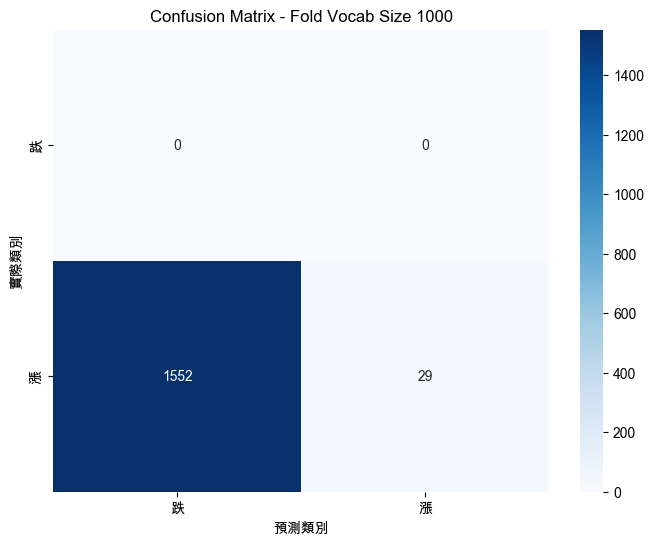

Testing Vocabulary Sizes:  33%|███▎      | 1/3 [00:03<00:07,  3.75s/it]


=== 使用 2000 個詞彙進行訓練 ===

詞彙數量: 2000
準確率: 0.0190

分類報告:
              precision    recall  f1-score   support

           跌       0.00      0.00      0.00         0
           漲       1.00      0.02      0.04      1581

    accuracy                           0.02      1581
   macro avg       0.50      0.01      0.02      1581
weighted avg       1.00      0.02      0.04      1581



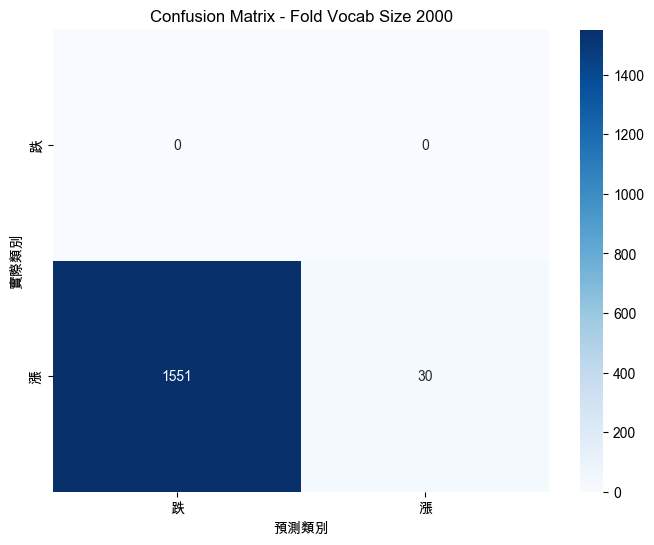

Testing Vocabulary Sizes:  67%|██████▋   | 2/3 [00:08<00:04,  4.20s/it]


=== 使用 3000 個詞彙進行訓練 ===

詞彙數量: 3000
準確率: 0.0133

分類報告:
              precision    recall  f1-score   support

           跌       0.00      0.00      0.00         0
           漲       1.00      0.01      0.03      1581

    accuracy                           0.01      1581
   macro avg       0.50      0.01      0.01      1581
weighted avg       1.00      0.01      0.03      1581



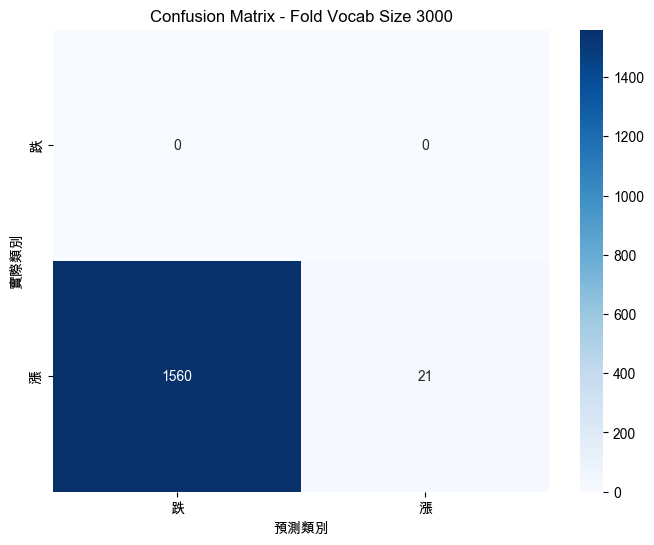

Testing Vocabulary Sizes: 100%|██████████| 3/3 [00:13<00:00,  4.40s/it]


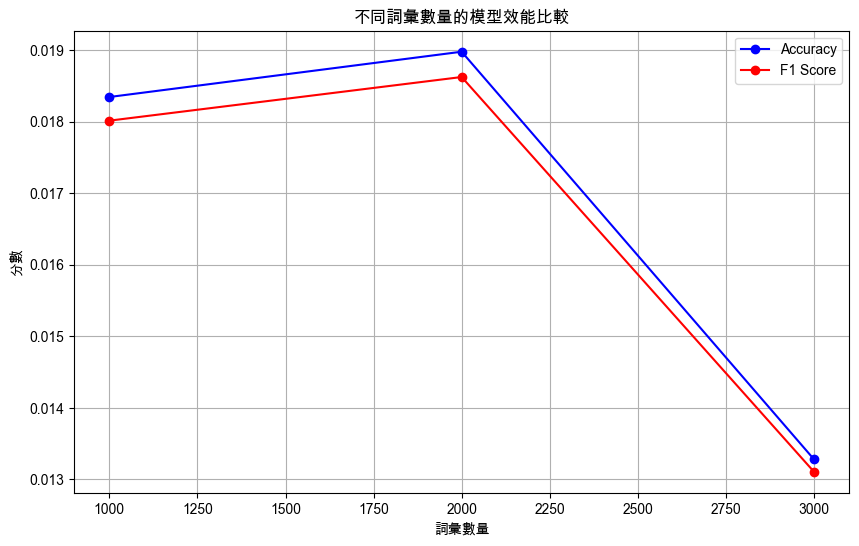


最佳模型使用 2000 個詞彙
最佳準確率: 0.0190


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # 用於繪製混淆矩陣
import warnings
warnings.filterwarnings('ignore')
# 設定中文字體
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # Mac 系統適用
plt.rcParams['axes.unicode_minus'] = False  # 讓負號正確顯示


def compare_feature_sizes(bearish_news_merged, bullish_news_merged, 
                         feature_sizes=[1000, 2000, 3000], test_size=0.2):
    """
    比較不同詞彙數量的模型效能
    """
    results = []
    
    for vocab_size in tqdm(feature_sizes, desc="Testing Vocabulary Sizes"):
        print(f"\n=== 使用 {vocab_size} 個詞彙進行訓練 ===")
        
        # 建立 pipeline
        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer(
                max_features=vocab_size,  # 調整詞彙數量
                min_df=5,
                max_df=0.95
            )),
            ('selector', SelectKBest(mutual_info_classif, k=int(vocab_size * 0.8))),  # 選取80%的特徵
            ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
        ])
        
        # 準備數據
        X = bearish_news_merged['all_tokens'].tolist() + bullish_news_merged['all_tokens'].tolist()
        y = np.array([0]*len(bearish_news_merged) + [1]*len(bullish_news_merged))
        
        # 時間序列分割
        split_idx = int(len(X) * (1 - test_size))
        X_train, X_test = X[:split_idx], X[split_idx:]
        y_train, y_test = y[:split_idx], y[split_idx:]
        
        # 訓練和評估e
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        
        # 計算各項指標
        accuracy = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred, 
                                    target_names=['跌', '漲'], 
                                    output_dict=True)
        cm = confusion_matrix(y_test, y_pred)
        
        # 儲存結果
        results.append({
            'vocab_size': vocab_size,
            'accuracy': accuracy,
            'f1_score': report['macro avg']['f1-score'],
            'confusion_matrix': cm,
            'report': report,
            'model': pipeline
        })
        
        # 顯示結果
        print(f"\n詞彙數量: {vocab_size}")
        print(f"準確率: {accuracy:.4f}")
        print("\n分類報告:")
        print(classification_report(y_test, y_pred, target_names=['跌', '漲']))
        plot_confusion_matrix(cm, f"Vocab Size {vocab_size}")
    
    # 繪製比較圖
    plt.figure(figsize=(10, 6))
    vocab_sizes = [r['vocab_size'] for r in results]
    accuracies = [r['accuracy'] for r in results]
    f1_scores = [r['f1_score'] for r in results]
    
    plt.plot(vocab_sizes, accuracies, 'b-o', label='Accuracy')
    plt.plot(vocab_sizes, f1_scores, 'r-o', label='F1 Score')
    plt.xlabel('詞彙數量')
    plt.ylabel('分數')
    plt.title('不同詞彙數量的模型效能比較')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # 顯示最佳結果
    best_result = max(results, key=lambda x: x['accuracy'])
    print(f"\n最佳模型使用 {best_result['vocab_size']} 個詞彙")
    print(f"最佳準確率: {best_result['accuracy']:.4f}")
    
    return results, best_result['model']

# 執行比較
print("開始比較不同詞彙數量的效能...")
results, best_model = compare_feature_sizes(bearish_news_merged, bullish_news_merged)

In [ ]:
X = bearish_news_merged['all_tokens'].tolist() + bullish_news_merged['all_tokens'].tolist()
y = np.array([0]*len(bearish_news_merged) + [1]*len(bullish_news_merged))

In [18]:
merged_news = pd.concat([bullish_news_merged, bearish_news_merged], ignore_index=True)

In [19]:
merged_news 

,post_time,title,content,Change,title_tokens,content_tokens,all_tokens
0,2023-01-04 19:04:09,渣打估美年底降息 美元Q1見頂回落,[NOWnews今日新聞]進入2023年，全球金融情勢依舊充滿許多不確定因子，包括疫情反覆、...,1,渣打 估 美 年底 降息 美元 Q 1 見 頂回 落,[ NOWnews 今日 新聞 ] 進入 2023年 ， 全球 金融 情勢 依舊 充滿 許多...,渣打 估 美 年底 降息 美元 Q 1 見 頂回 落 [ NOWnews 今日 新聞 ]...
1,2023-01-16 09:10:19,快訊／虎年封關倒數2日！台積電漲6元衝506元 台股漲逾100點拚萬五,記者戴玉翔／台北報導美股3大指數13日全面上揚，道瓊指數終盤上漲112.64點，漲幅0.33...,1,快訊 ／ 虎年 封關 倒數 2 日 ！ 台積電 漲 6 元 衝 506 元 台股 漲 逾...,記者 戴玉翔 ／ 台北 報導 美股 3 大 指數 13 日 全面 上揚 ， 道瓊 指數 終盤...,快訊 ／ 虎年 封關 倒數 2 日 ！ 台積電 漲 6 元 衝 506 元 台股 漲 逾...
2,2023-01-16 11:03:36,電金生技領漲 台股盤中勁揚136點挑戰萬五關卡,（中央社記者張建中台北16日電）美股13日震盪收高，台股今天同步走高，盤中一度大漲136.7...,1,電金 生技 領 漲 台股 盤 中 勁揚 136 點 挑戰 萬五 關卡,（ 中央社 記者 張建中 台北 16 日 電 ） 美股 13 日 震盪 收高 ， 台股 今天...,電金 生技 領 漲 台股 盤 中 勁揚 136 點 挑戰 萬五 關卡 （ 中央社 記者 ...
3,2023-01-16 13:42:47,台積電上漲5元 台股揚升102點突破14900點,（中央社記者張建中台北16日電）美股13日震盪收高，台股今天隨著同步揚升，指數終場上揚102...,1,台積電 上漲 5 元 台股 揚升 102 點 突破 14900 點,（ 中央社 記者 張建中 台北 16 日 電 ） 美股 13 日 震盪 收高 ， 台股 今天...,台積電 上漲 5 元 台股 揚升 102 點 突破 14900 點 （ 中央社 記者 張...
4,2023-01-16 13:55:05,封關倒數 台股揚升102點站上14900點,美股13日震盪收高，台股今天隨著同步揚升，指數終場上揚102.88點，突破14900點關卡，...,1,封關 倒數 台股 揚升 102 點 站上 14900 點,美股 13 日 震盪 收高 ， 台股 今天 隨著 同步 揚升 ， 指數 終場 上揚 102....,封關 倒數 台股 揚升 102 點 站上 14900 點 美股 13 日 震盪 收高 ，...
...,...,...,...,...,...,...,...
7899,2023-12-21 22:59:43,[新聞] 美國下修第三季GDP成長 台指期夜盤反彈,原文標題： 美國下修第三季GDP成長 台指期夜盤反彈 原文連結： https://www....,-1,[ 新聞 ] 美國 下修 第三 季 GDP 成長 台 指期 夜盤 反彈,原文 標題 ： 美國 下修 第三 季 GDP 成長 台 指期 夜盤 反彈 原...,[ 新聞 ] 美國 下修 第三 季 GDP 成長 台 指期 夜盤 反彈 原文 標題 ...
7900,2023-12-23 23:27:03,[新聞] 台股醞釀雙軋行情 軋空單軋外資空手蠢動,原文標題：台股醞釀新一波雙軋行情 大盤軋空單、軋外資空手蠢動 原文連結：https://u...,-1,[ 新聞 ] 台股 醞釀 雙軋 行情 軋空單軋 外資 空手 蠢動,原文 標題 ： 台股 醞釀 新 一 波 雙軋 行情 大盤 軋空單 、 軋 外資 空手 蠢...,[ 新聞 ] 台股 醞釀 雙軋 行情 軋空單軋 外資 空手 蠢動 原文 標題 ： 台...
7901,2023-12-27 11:21:16,[心得] 年度績效與策略分享,股版潛水十幾年首發，感謝股版所有大方分享知識的同好，讓我從一個非金融本科系的門 外漢，一路跌...,-1,[ 心得 ] 年度 績效 與 策略 分享,股版 潛水 十幾 年 首發 ， 感謝 股版 所有 大方 分享 知識 的 同好 ， 讓 我 從...,[ 心得 ] 年度 績效 與 策略 分享 股版 潛水 十幾 年 首發 ， 感謝 股版 所...
7902,2023-12-27 13:52:49,[新聞] 標普：美國房價指數創歷史新高、連續第9-,1.發文前請先詳閱[新聞]分類發文規範，未依規範發文將受處份。 2.連結過長請善用 http...,-1,[ 新聞 ] 標普 ： 美國 房價 指數 創 歷史 新高 、 連續 第9 -,1 . 發文 前 請 先 詳閱 [ 新聞 ] 分類 發文 規範 ， 未 依 規範 發文 將 ...,[ 新聞 ] 標普 ： 美國 房價 指數 創 歷史 新高 、 連續 第9 - 1 . 發...


In [20]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import mutual_info_classif
import pandas as pd
import matplotlib.pyplot as plt

tfidf_vectorizer = TfidfVectorizer(max_df=0.9, min_df=5)  # 可以微調 max_df, min_df
X_tfidf = tfidf_vectorizer.fit_transform(merged_news['all_tokens'])

# Step 2: 建立對應的標籤 y（0=down, 1=up）
y = merged_news['Change']  # 'Change' 是股價漲跌的標籤，0 代表下跌，1 代表上升

# Step 1: 拿出 TF-IDF 向量與詞彙
terms = tfidf_vectorizer.get_feature_names_out()

# Step 2: 將 TF-IDF 向量轉成 DataFrame
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=terms)

# Step 3: 加上 label（0 = down, 1 = up）
tfidf_df['label'] = y.values

# Step 4: 分別計算 bullish & bearish 的平均 TF-IDF
bullish_mean = tfidf_df[tfidf_df['label'] == 1].drop(columns='label').mean()
# bearish_mean = tfidf_df[tfidf_df['label'] == 0].drop(columns='label').mean()
bearish_mean = tfidf_df[tfidf_df['label'] == -1].drop(columns='label').mean().fillna(0)

# Step 5: 找出在 bullish 中出現頻率高的詞
top_bullish = bullish_mean.sort_values(ascending=False).head(30)
# Step 6: 找出在 bearish 中出現頻率高的詞
top_bearish = bearish_mean[bearish_mean > 0].sort_values(ascending=False).head(30)
# top_bearish = bearish_mean.sort_values(ascending=False).head(30)

# 顯示結果
print("🔥 Bullish 關鍵詞：")
print(top_bullish)

print("\n❄️ Bearish 關鍵詞：")
print(top_bearish)

🔥 Bullish 關鍵詞：
指數     0.045179
美元     0.040911
美國     0.027023
上揚     0.025821
台股     0.022324
市場     0.021093
上漲     0.020428
價格     0.020364
下跌     0.019057
報導     0.018846
升息     0.016432
股市     0.016161
類股     0.016136
美股     0.015908
台北     0.015802
經濟     0.015732
記者     0.015454
殖利率    0.015388
預期     0.015267
數據     0.015062
ai     0.014508
營收     0.014466
今年     0.014285
表現     0.014162
股價     0.014047
公債     0.014004
新高     0.013738
通膨     0.013340
時報     0.013170
10     0.012916
dtype: float64

❄️ Bearish 關鍵詞：
指數     0.041180
美元     0.041077
美國     0.025645
上揚     0.025080
台股     0.025004
市場     0.023087
上漲     0.020642
價格     0.019119
下跌     0.018626
營收     0.018282
報導     0.017703
殖利率    0.017007
預期     0.016498
美股     0.016481
股市     0.015546
台北     0.015504
記者     0.015326
經濟     0.015218
類股     0.015013
數據     0.014766
公債     0.014686
升息     0.014612
10     0.013895
股價     0.013857
表現     0.013719
時報     0.013241
聯準會    0.012963
黃金     0.012957
今年     0.012814
ai     0.

#### PCA

執行 PCA 分析...


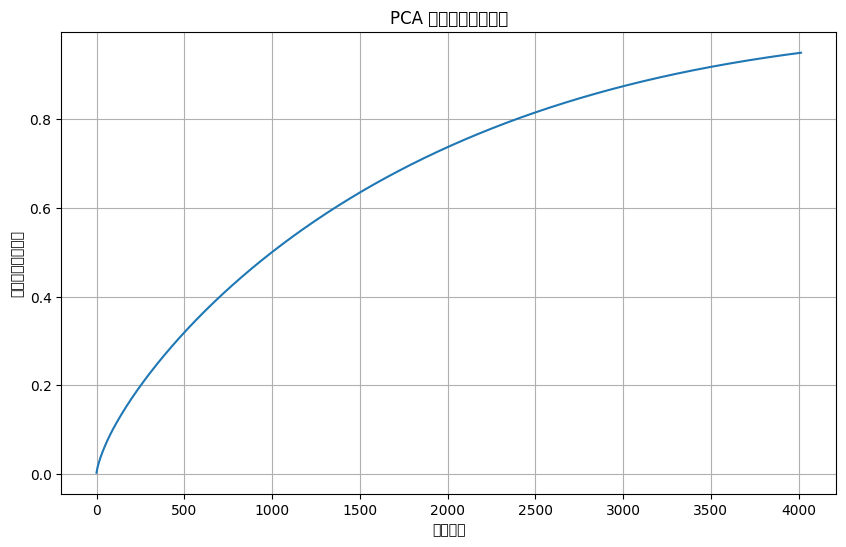

特徵總數: 7510
解釋95%方差所需的組件數: 4015

使用 PCA 降維後比較模型...
使用 4015 個主成分進行分析
解釋方差比例: 0.9487


🔍 Test Size Progress:   0%|          | 0/9 [00:00<?, ?it/s]


ValueError: Negative values in data passed to MultinomialNB (input X).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from tqdm import tqdm  # ✅ 加上 tqdm
# 假設 X, y 已經定義好了

# 1. 添加 PCA 分析函數
def analyze_pca_components(X, n_components=0.95):
    """
    分析 PCA 組成並繪製解釋方差圖
    """
    # 標準化
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 執行 PCA
    pca = PCA(n_components=n_components)
    pca.fit(X_scaled)
    
    # 繪製解釋方差圖
    plt.figure(figsize=(10, 6))
    plt.plot(np.cumsum(pca.explained_variance_ratio_))
    plt.xlabel('組件數量')
    plt.ylabel('累積解釋方差比例')
    plt.title('PCA 組件累積解釋方差')
    plt.grid(True)
    plt.show()
    
    # 輸出重要資訊
    print(f"特徵總數: {X.shape[1]}")
    n_components_95 = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1
    print(f"解釋95%方差所需的組件數: {n_components_95}")
    
    return pca, n_components_95

# 2. 修改原有的模型比較代碼
# 3. 執行分析
# 準備數據
X_selected = tfidf_df.drop(columns='label')
y = tfidf_df['label']

# 執行 PCA 分析
print("執行 PCA 分析...")
pca_analysis, suggested_components = analyze_pca_components(X_selected)


In [ ]:

def compare_models_with_pca(X, y, test_sizes, n_components=None):
    """
    使用 PCA 降維後比較不同模型
    """
    # 標準化
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # PCA 轉換
    if n_components is None:
        _, n_components = analyze_pca_components(X_scaled)
    
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)
    
    print(f"使用 {n_components} 個主成分進行分析")
    print(f"解釋方差比例: {pca.explained_variance_ratio_.sum():.4f}")
    
    # ...existing models code...
    models = {
        # 'MultinomialNB': MultinomialNB(),
        # 'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
        # 'KNN (k=7)': KNeighborsClassifier(n_neighbors=7),
        'Random Forest': RandomForestClassifier(random_state=42),
        # 'Decision Tree': DecisionTreeClassifier(random_state=42),
        'Logistic Regression': LogisticRegression(random_state=42),
        'SVM': SVC(random_state=42),
        'MLP': MLPClassifier(random_state=42, max_iter=1000)
    }
    
    accuracy_results = {name: [] for name in models.keys()}
    best_model_info = {}
    
    # 使用 PCA 轉換後的特徵進行訓練
    for test_size in tqdm(test_sizes, desc="🔍 Test Size Progress"):
        X_train, X_test, y_train, y_test = train_test_split(
            X_pca, y, test_size=test_size, random_state=42
        )
        
        best_acc = 0
        for name, model in models.items():
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            acc = accuracy_score(y_test, y_pred)
            accuracy_results[name].append(acc)
            
            if acc > best_acc:
                best_acc = acc
                best_model_info[test_size] = {
                    'model': name,
                    'accuracy': acc,
                    'confusion_matrix': confusion_matrix(y_test, y_pred)
                }
    
    return accuracy_results, best_model_info, pca

# 使用建議的組件數進行模型比較
print("\n使用 PCA 降維後比較模型...")
accuracy_results, best_model_info, fitted_pca = compare_models_with_pca(
    X_selected, 
    y, 
    test_sizes=np.arange(0.1, 1.0, 0.1),
    n_components=suggested_components
)



使用 PCA 降維後比較模型...
使用 4015 個主成分進行分析
解釋方差比例: 0.9487


🔍 Test Size Progress: 100%|██████████| 9/9 [12:57<00:00, 86.37s/it] 


NameError: name 'test_sizes' is not defined

<Figure size 1200x600 with 0 Axes>

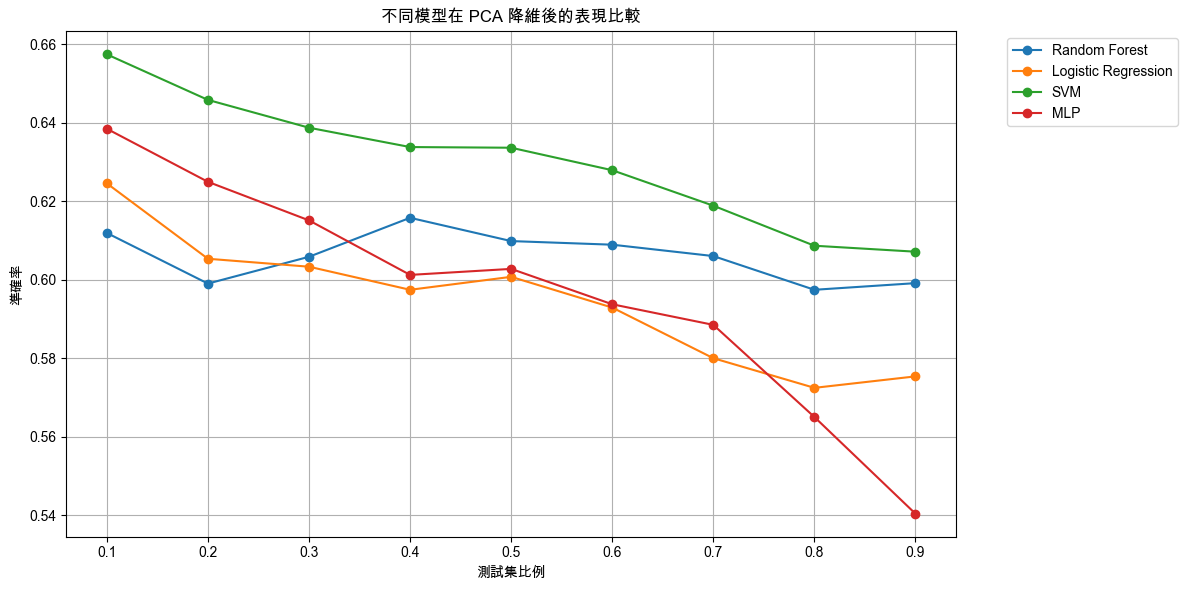

In [40]:
test_sizes=np.arange(0.1, 1.0, 0.1)
# 4. 視覺化結果
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # Mac 系統適用
plt.rcParams['axes.unicode_minus'] = False  # 讓負號正確顯示

plt.figure(figsize=(12, 6))
for model_name, accuracies in accuracy_results.items():
    plt.plot(test_sizes, np.ravel(accuracies), marker='o', label=model_name)

plt.xlabel('測試集比例')
plt.ylabel('準確率')
plt.title('不同模型在 PCA 降維後的表現比較')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [71]:
Sorted_shangyang_transaction_df

,代號,名稱,年月日,開盤價(元),最高價(元),最低價(元),收盤價(元),成交量(千股),成交值(千元),報酬率％,...,高低價差%,次日開盤參考價,次日漲停價,次日跌停價,注意股票(A),處置股票(D),全額交割(Y),市場別,next_day_return,date_only
0,6222,上揚,2023-01-03,14.65,14.65,14.65,14.65,0,12,0.0000,...,0.0000,14.65,16.10,13.20,NaN,NaN,NaN,OTC,0.0000,2023-01-03
1,6222,上揚,2023-01-04,14.65,14.65,14.65,14.65,0,0,0.0000,...,0.0000,14.65,16.10,13.20,NaN,NaN,NaN,OTC,2.7304,2023-01-04
2,6222,上揚,2023-01-05,15.05,15.05,15.05,15.05,3,45,2.7304,...,0.0000,15.05,16.55,13.55,NaN,NaN,NaN,OTC,0.6645,2023-01-05
3,6222,上揚,2023-01-06,15.10,15.15,15.10,15.15,3,45,0.6645,...,0.3322,15.15,16.65,13.65,NaN,NaN,NaN,OTC,-2.3102,2023-01-06
4,6222,上揚,2023-01-09,14.85,14.85,14.80,14.80,4,59,-2.3102,...,0.3300,14.80,16.25,13.35,NaN,NaN,NaN,OTC,1.3514,2023-01-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
234,6222,上揚,2023-12-25,40.05,41.20,38.65,38.65,639,25294,-9.9068,...,5.9441,38.65,42.50,34.80,NaN,D,NaN,OTC,-9.9612,2023-12-25
235,6222,上揚,2023-12-26,34.80,35.90,34.80,34.80,501,17488,-9.9612,...,2.8461,34.80,38.25,31.35,NaN,NaN,NaN,OTC,0.0000,2023-12-26
236,6222,上揚,2023-12-27,31.80,36.30,31.35,34.80,770,24916,0.0000,...,14.2241,34.80,38.25,31.35,NaN,NaN,NaN,OTC,-4.8851,2023-12-27
237,6222,上揚,2023-12-28,33.15,33.70,32.25,33.10,313,10431,-4.8851,...,4.1667,33.10,36.40,29.80,A,NaN,NaN,OTC,-1.8127,2023-12-28


In [ ]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
from sklearn.metrics import confusion_matrix, accuracy_score

def backtest_news_stock(news_df, transaction_df, start_date, end_date):
    results = []

    for month in pd.date_range(start_date, end_date, freq='M'):
        month_start = month.strftime('%Y-%m-01')
        month_end = (month + timedelta(days=32)).replace(day=1) - timedelta(days=1)
        month_end = month_end.strftime('%Y-%m-%d')

        # 篩選該月的新聞和交易數據
        news_in_month = filtered_news[(filtered_news['date'] >= month_start) & (filtered_news['date'] <= month_end)]
        transactions_in_month = transaction_df[(transaction_df['Previous_date'] >= month_start) & (transaction_df['Previous_date'] <= month_end)]

        if news_in_month.empty or transactions_in_month.empty:
            continue

        # 預測
        x = np.vstack(news_in_month['vector'])
        predictions = voting_clf.predict(x)

        # 確保交易數據的時間是對應的
        transactions_in_month = transactions_in_month.set_index('Previous_date').reindex(news_in_month['post_time']).reset_index()
        true_changes = transactions_in_month['Change'].values

        # 計算accuracy
        correct_predictions = (predictions == true_changes) | (true_changes == 2)
        accuracy = np.mean(correct_predictions)

        # 儲存結果
        results.append({
            'month': month.strftime('%Y-%m'),
            'accuracy': accuracy,
            'predictions_made': len(predictions),
            'correct_predictions': np.sum(correct_predictions)
        })

    return pd.DataFrame(results)


# 從2022年7月開始預測直到2024年2月
backtest_results = backtest_news_stock(
    filtered_news,
    Sorted_shangyang_transaction_df,
    '2023-01-03',
    '2023-12-29'
)

# 輸出預測結果
print(backtest_results)



In [87]:
news_df = news_df.rename(columns={'date_only': 'date'})

In [89]:
news_df

,id,p_type,s_name,s_area_name,post_time,title,author,content,page_url,content_type,date
0,1672541649216_YahooNews,news,Yahoo新聞,股市匯市,2023-01-01 10:45:18,年關將近！準備換新鈔 央行「鈔前部署」3招辨真假,三立新聞網,記者戴玉翔／綜合報導新的一年即將到來，而在農曆年前，台灣人都有換新鈔的習慣，中央銀行預計會在...,https://tw.news.yahoo.com/%E5%B9%B4%E9%97%9C%E...,NaN,2023-01-01
1,1672546740027_YahooNews,news,Yahoo新聞,股市匯市,2023-01-01 12:12:25,快加油！油價明調漲 汽油貴0.4元、柴油調降0.1元,王馨儀,台灣中油公司自明（2）日凌晨零時起汽油調漲0.4元、柴油調降0.1元，參考零售價格分別為92...,https://tw.news.yahoo.com/%E5%BF%AB%E5%8A%A0%E...,NaN,2023-01-01
2,1672564766561_YahooNews,news,Yahoo新聞,股市匯市,2023-01-01 17:11:26,2023台股展望！農曆年還有紅包行情？,民視新聞網,民視新聞／綜合報導台北股市已經在2022年經歷過大熊市，那麼在即將到來的2023年，有沒有機...,https://tw.news.yahoo.com/2023%E5%8F%B0%E8%82%...,NaN,2023-01-01
3,1672567021802_YahooNews,news,Yahoo新聞,股市匯市,2023-01-01 17:44:07,「反生命」喊話楊文科 要求終止生命園區開發,民視新聞網,民視新聞／ 綜合報導新竹縣的元旦升旗典禮，發生場外插曲，原來是新豐、湖口兩鄉居民，組成的反生...,https://tw.news.yahoo.com/%E5%8F%8D%E7%94%9F%E...,NaN,2023-01-01
4,1672567849204_YahooNews,news,Yahoo新聞,股市匯市,2023-01-01 18:01:02,2023台股展望！農曆年還有紅包行情？,NaN,民視新聞／綜合報導台北股市已經在2022年經歷過大熊市，那麼在即將到來的2023年，有沒有機...,https://tw.news.yahoo.com/2023%E5%8F%B0%E8%82%...,NaN,2023-01-01
...,...,...,...,...,...,...,...,...,...,...,...
625767,1704029253846_PTT02R,bbs,Ptt,Stock,2023-12-31 21:25:05,Re: [新聞] 2024年AI PC全面引爆!謝金河揭緯創等3檔接,Tox,IDC 2023 Q3 PC https://i.imgur.com/VtPXIeT.png...,http://www.ptt.cc/bbs/Stock/M.1704029109.A.BED...,NaN,2023-12-31
625768,1704029391834_PTT02R,bbs,Ptt,Stock,2023-12-31 21:28:28,[心得] 本保羅2023年的操作回顧及經驗分享,Paul1021,各位股板的板友大家好喔 是這樣子的 保羅要跟大家分享2023年保羅的操作回顧 以及經驗...,http://www.ptt.cc/bbs/Stock/M.1704029310.A.4D6...,NaN,2023-12-31
625769,1704033954867_PTT02R,bbs,Ptt,Stock,2023-12-31 22:44:23,2023年年報,athlon3200,先上圖，證券只能查半年損益 https://i.imgur.com/n4bCvtG.jpg ...,http://www.ptt.cc/bbs/Stock/M.1704033865.A.9BB...,NaN,2023-12-31
625770,1704035621409_PTT02R,bbs,Ptt,Stock,2023-12-31 23:11:37,[請益] 台灣晶圓代工的強項,greedyba,我在鑽研台灣晶圓代工概念股的優劣勢 台灣晶圓代工在全世界排第一梯次 可是晶圓代工需要的化學原...,http://www.ptt.cc/bbs/Stock/M.1704035500.A.72E...,NaN,2023-12-31


In [92]:
filtered_news_merged

,date,title,content,Change
69,2023-01-04 19:04:09,渣打估美年底降息 美元Q1見頂回落,[NOWnews今日新聞]進入2023年，全球金融情勢依舊充滿許多不確定因子，包括疫情反覆、...,1
76,2023-01-05 04:10:00,美債殖利率飆升 銀行警戒,2022全年美債殖利率一路飆升，銀行業者大敲警鐘，更主動進行壓力測試。根據金融圈人士透露，已...,0
84,2023-01-05 09:38:29,股匯齊揚 台幣早盤升破30.7元,[NOWnews今日新聞]美國聯準會（Fed）公布2022年12月會議紀要，顯示聯準會官員仍...,0
87,2023-01-05 11:08:09,台積電帶領半導體股勁揚 台股盤中漲逾百點,（中央社記者張建中台北5日電）美股收高，費城半導體指數勁揚逾2%。台股今天在台積電股價反彈，...,0
103,2023-01-06 04:10:00,需求回溫 金像電、矽創權證夯,台股進入2023年，電子業陸續進入庫存調整階段，法人認為金像電（2368）2023年將受惠網...,-1
...,...,...,...,...
286521,2023-12-27 11:21:16,[心得] 年度績效與策略分享,股版潛水十幾年首發，感謝股版所有大方分享知識的同好，讓我從一個非金融本科系的門 外漢，一路跌...,-1
286530,2023-12-27 13:52:49,[新聞] 標普：美國房價指數創歷史新高、連續第9-,1.發文前請先詳閱[新聞]分類發文規範，未依規範發文將受處份。 2.連結過長請善用 http...,-1
286558,2023-12-27 19:18:45,[新聞],-------------------------------發文提醒-----------...,-1
286665,2023-12-29 12:51:09,[新聞] 萬八一定見 谷月涵拋台股4箭 謝金河按讚,-------------------------------發文提醒-----------...,0


In [95]:
news_df.shape

(286801, 11)

In [97]:
Sorted_shangyang_transaction_df.shape

(239, 38)

In [102]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 假設你的新聞 DataFrame 中有 "text" 欄位
tfidf_vectorizer = TfidfVectorizer(max_features=3000, min_df=5, max_df=0.95)
# 對文本欄位做向量化
filtered_news_merged['vector'] = list(tfidf_vectorizer.fit_transform(filtered_news_merged['content']).toarray())

In [110]:
Sorted_shangyang_transaction_df = Sorted_shangyang_transaction_df.rename(columns={'年月日': 'date'})
Sorted_shangyang_transaction_df

,代號,名稱,date,開盤價(元),最高價(元),最低價(元),收盤價(元),成交量(千股),成交值(千元),報酬率％,...,次日開盤參考價,次日漲停價,次日跌停價,注意股票(A),處置股票(D),全額交割(Y),市場別,Change,Previous_date,next_day_return
0,6222,上揚,2023-01-03,14.65,14.65,14.65,14.65,0,12,0.0000,...,14.65,16.10,13.20,NaN,NaN,NaN,OTC,0,2023-01-02,0.0000
1,6222,上揚,2023-01-04,14.65,14.65,14.65,14.65,0,0,0.0000,...,14.65,16.10,13.20,NaN,NaN,NaN,OTC,0,2023-01-03,2.7304
2,6222,上揚,2023-01-05,15.05,15.05,15.05,15.05,3,45,2.7304,...,15.05,16.55,13.55,NaN,NaN,NaN,OTC,1,2023-01-04,0.6645
3,6222,上揚,2023-01-06,15.10,15.15,15.10,15.15,3,45,0.6645,...,15.15,16.65,13.65,NaN,NaN,NaN,OTC,0,2023-01-05,-2.3102
4,6222,上揚,2023-01-09,14.85,14.85,14.80,14.80,4,59,-2.3102,...,14.80,16.25,13.35,NaN,NaN,NaN,OTC,-1,2023-01-08,1.3514
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
234,6222,上揚,2023-12-25,40.05,41.20,38.65,38.65,639,25294,-9.9068,...,38.65,42.50,34.80,NaN,D,NaN,OTC,-1,2023-12-24,-9.9612
235,6222,上揚,2023-12-26,34.80,35.90,34.80,34.80,501,17488,-9.9612,...,34.80,38.25,31.35,NaN,NaN,NaN,OTC,-1,2023-12-25,0.0000
236,6222,上揚,2023-12-27,31.80,36.30,31.35,34.80,770,24916,0.0000,...,34.80,38.25,31.35,NaN,NaN,NaN,OTC,0,2023-12-26,-4.8851
237,6222,上揚,2023-12-28,33.15,33.70,32.25,33.10,313,10431,-4.8851,...,33.10,36.40,29.80,A,NaN,NaN,OTC,-1,2023-12-27,-1.8127


In [75]:
filtered_news_merged

,post_time,title,content,Change
69,2023-01-04 19:04:09,渣打估美年底降息 美元Q1見頂回落,[NOWnews今日新聞]進入2023年，全球金融情勢依舊充滿許多不確定因子，包括疫情反覆、...,1
76,2023-01-05 04:10:00,美債殖利率飆升 銀行警戒,2022全年美債殖利率一路飆升，銀行業者大敲警鐘，更主動進行壓力測試。根據金融圈人士透露，已...,0
84,2023-01-05 09:38:29,股匯齊揚 台幣早盤升破30.7元,[NOWnews今日新聞]美國聯準會（Fed）公布2022年12月會議紀要，顯示聯準會官員仍...,0
87,2023-01-05 11:08:09,台積電帶領半導體股勁揚 台股盤中漲逾百點,（中央社記者張建中台北5日電）美股收高，費城半導體指數勁揚逾2%。台股今天在台積電股價反彈，...,0
103,2023-01-06 04:10:00,需求回溫 金像電、矽創權證夯,台股進入2023年，電子業陸續進入庫存調整階段，法人認為金像電（2368）2023年將受惠網...,-1
...,...,...,...,...
286521,2023-12-27 11:21:16,[心得] 年度績效與策略分享,股版潛水十幾年首發，感謝股版所有大方分享知識的同好，讓我從一個非金融本科系的門 外漢，一路跌...,-1
286530,2023-12-27 13:52:49,[新聞] 標普：美國房價指數創歷史新高、連續第9-,1.發文前請先詳閱[新聞]分類發文規範，未依規範發文將受處份。 2.連結過長請善用 http...,-1
286558,2023-12-27 19:18:45,[新聞],-------------------------------發文提醒-----------...,-1
286665,2023-12-29 12:51:09,[新聞] 萬八一定見 谷月涵拋台股4箭 謝金河按讚,-------------------------------發文提醒-----------...,0


In [107]:
Sorted_shangyang_transaction_df

,代號,名稱,年月日,開盤價(元),最高價(元),最低價(元),收盤價(元),成交量(千股),成交值(千元),報酬率％,...,次日開盤參考價,次日漲停價,次日跌停價,注意股票(A),處置股票(D),全額交割(Y),市場別,Change,Previous_date,next_day_return
0,6222,上揚,2023-01-03,14.65,14.65,14.65,14.65,0,12,0.0000,...,14.65,16.10,13.20,NaN,NaN,NaN,OTC,0,2023-01-02,0.0000
1,6222,上揚,2023-01-04,14.65,14.65,14.65,14.65,0,0,0.0000,...,14.65,16.10,13.20,NaN,NaN,NaN,OTC,0,2023-01-03,2.7304
2,6222,上揚,2023-01-05,15.05,15.05,15.05,15.05,3,45,2.7304,...,15.05,16.55,13.55,NaN,NaN,NaN,OTC,1,2023-01-04,0.6645
3,6222,上揚,2023-01-06,15.10,15.15,15.10,15.15,3,45,0.6645,...,15.15,16.65,13.65,NaN,NaN,NaN,OTC,0,2023-01-05,-2.3102
4,6222,上揚,2023-01-09,14.85,14.85,14.80,14.80,4,59,-2.3102,...,14.80,16.25,13.35,NaN,NaN,NaN,OTC,-1,2023-01-08,1.3514
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
234,6222,上揚,2023-12-25,40.05,41.20,38.65,38.65,639,25294,-9.9068,...,38.65,42.50,34.80,NaN,D,NaN,OTC,-1,2023-12-24,-9.9612
235,6222,上揚,2023-12-26,34.80,35.90,34.80,34.80,501,17488,-9.9612,...,34.80,38.25,31.35,NaN,NaN,NaN,OTC,-1,2023-12-25,0.0000
236,6222,上揚,2023-12-27,31.80,36.30,31.35,34.80,770,24916,0.0000,...,34.80,38.25,31.35,NaN,NaN,NaN,OTC,0,2023-12-26,-4.8851
237,6222,上揚,2023-12-28,33.15,33.70,32.25,33.10,313,10431,-4.8851,...,33.10,36.40,29.80,A,NaN,NaN,OTC,-1,2023-12-27,-1.8127


##### tfidf

### Training

In [ ]:
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score, classification_report
# from sklearn.feature_selection import SelectKBest, mutual_info_classif

# # Step 1: 使用 SelectKBest 選擇最具區分力的特徵
# selector = SelectKBest(score_func=mutual_info_classif, k=1000)  # k=1000表示選擇前1000個特徵
# X_selected = selector.fit_transform(tfidf_df.drop(columns='label'), tfidf_df['label'])

# # Step 2: 分割數據集為訓練集和測試集
# X_train, X_test, y_train, y_test = train_test_split(X_selected, tfidf_df['label'], test_size=0.2, random_state=42)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from tqdm import tqdm  # ✅ 加上 tqdm
# 假設 X, y 已經定義好了

test_sizes = np.arange(0.1, 1.0, 0.1)

models = {
    'MultinomialNB': MultinomialNB(),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'KNN (k=7)': KNeighborsClassifier(n_neighbors=7),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42),
    'SVM': SVC(random_state=42),
    'MLP': MLPClassifier(random_state=42, max_iter=1000)
}

# 儲存準確率
accuracy_results = {name: [] for name in models.keys()}
best_model_info = {}


# 直接用 tfidf_df.drop(columns='label') 當作特徵
X_selected = tfidf_df.drop(columns='label')
y = tfidf_df['label']


In [ ]:
X_selected 

,00,000,0002,0004,0009,000億,000萬,0010,0013,0018,...,齊漲,齊發,齊紅,齊跌,齊黑,龍湖,龍頭,龍頭廠,龍頭股,龐大
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7899,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7900,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7901,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7902,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:

# 外層：不同 test size
for test_size in tqdm(test_sizes, desc="🔍 Test Size Progress"):
    print(f"\n🧪 Test Size: {test_size:.1f}")
    X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=test_size, random_state=42)

    best_model = None
    best_acc = 0
    best_cm = None

    # 內層：每個模型
    for name, model in models.items():
        print(f"➡️ Training model: {name}")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)

        accuracy_results[name].append(acc)

        if acc > best_acc:
            best_acc = acc
            best_model = name
            best_cm = cm

    best_model_info[test_size] = {
        'model': best_model,
        'accuracy': best_acc,
        'confusion_matrix': best_cm
    }

    print(f"✅ Best model for test size {test_size:.1f}: {best_model} with accuracy {best_acc:.4f}")
    

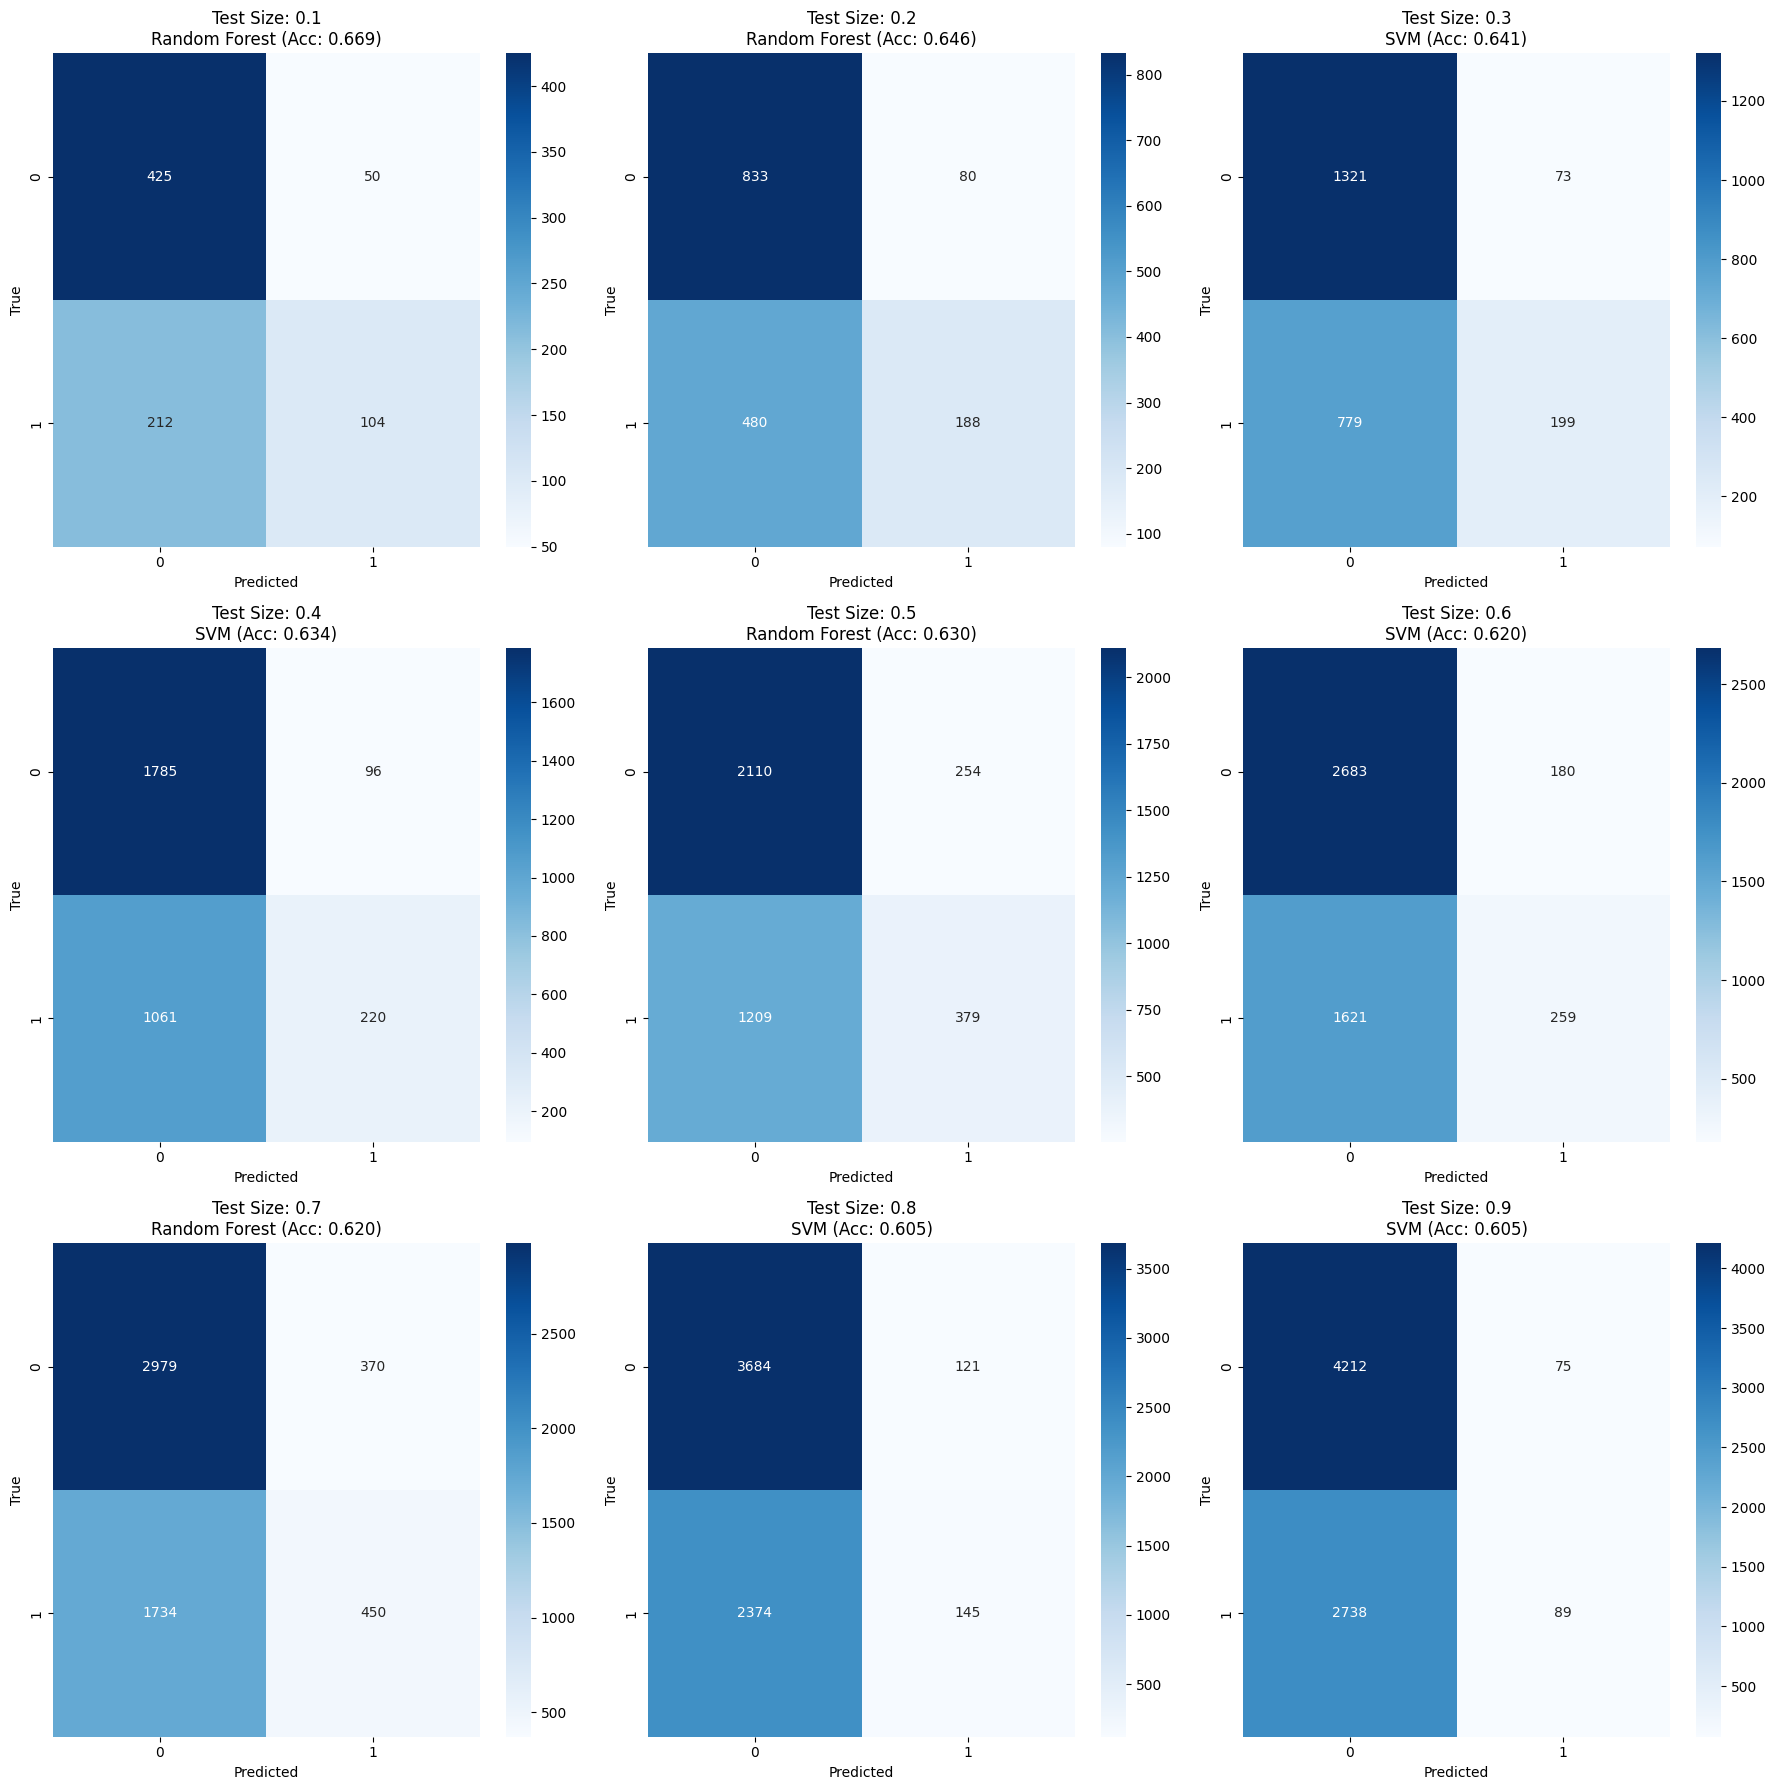

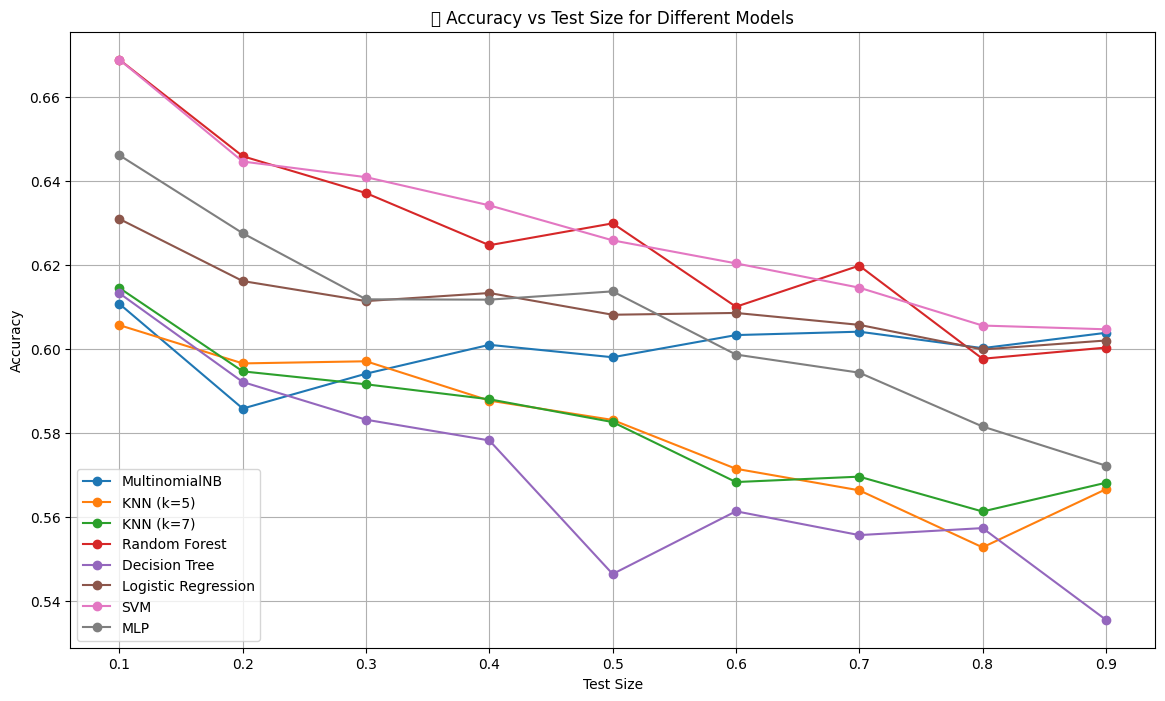

In [ ]:

# 畫出 Confusion Matrix
fig, axs = plt.subplots(3, 3, figsize=(18, 18))
axs = axs.flatten()

for i, (test_size, info) in enumerate(best_model_info.items()):
    cm = info['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axs[i])
    axs[i].set_title(f"Test Size: {test_size:.1f}\n{info['model']} (Acc: {info['accuracy']:.3f})")
    axs[i].set_xlabel("Predicted")
    axs[i].set_ylabel("True")

plt.tight_layout()
plt.show()

# 畫出各模型在不同 test size 下的準確率
plt.figure(figsize=(14, 8))
for name, accs in accuracy_results.items():
    plt.plot(test_sizes, accs, marker='o', label=name)

plt.xlabel("Test Size")
plt.ylabel("Accuracy")
plt.title("📊 Accuracy vs Test Size for Different Models")
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

##### Mutual Information

In [ ]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# 計算 mutual information 分數
selector = SelectKBest(score_func=mutual_info_classif, k=1000)  # 或 k='all' 先看分數分布
X_selected = selector.fit_transform(tfidf_df.drop(columns='label'), tfidf_df['label'])


# 如果要知道選了哪些詞
selected_terms = tfidf_df.drop(columns='label').columns[selector.get_support()]

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from tqdm import tqdm  # ✅ 加上 tqdm
# 假設 X, y 已經定義好了

test_sizes = np.arange(0.1, 1.0, 0.1)

models = {
    'MultinomialNB': MultinomialNB(),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'KNN (k=7)': KNeighborsClassifier(n_neighbors=7),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42),
    'SVM': SVC(random_state=42),
    'MLP': MLPClassifier(random_state=42, max_iter=1000)
}

# 儲存準確率
accuracy_results = {name: [] for name in models.keys()}
best_model_info = {}


# 外層：不同 test size
for test_size in tqdm(test_sizes, desc="🔍 Test Size Progress"):
    print(f"\n🧪 Test Size: {test_size:.1f}")
    X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=test_size, random_state=42)

    best_model = None
    best_acc = 0
    best_cm = None

    # 內層：每個模型
    for name, model in models.items():
        print(f"➡️ Training model: {name}")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)

        accuracy_results[name].append(acc)

        if acc > best_acc:
            best_acc = acc
            best_model = name
            best_cm = cm

    best_model_info[test_size] = {
        'model': best_model,
        'accuracy': best_acc,
        'confusion_matrix': best_cm
    }

    print(f"✅ Best model for test size {test_size:.1f}: {best_model} with accuracy {best_acc:.4f}")
    

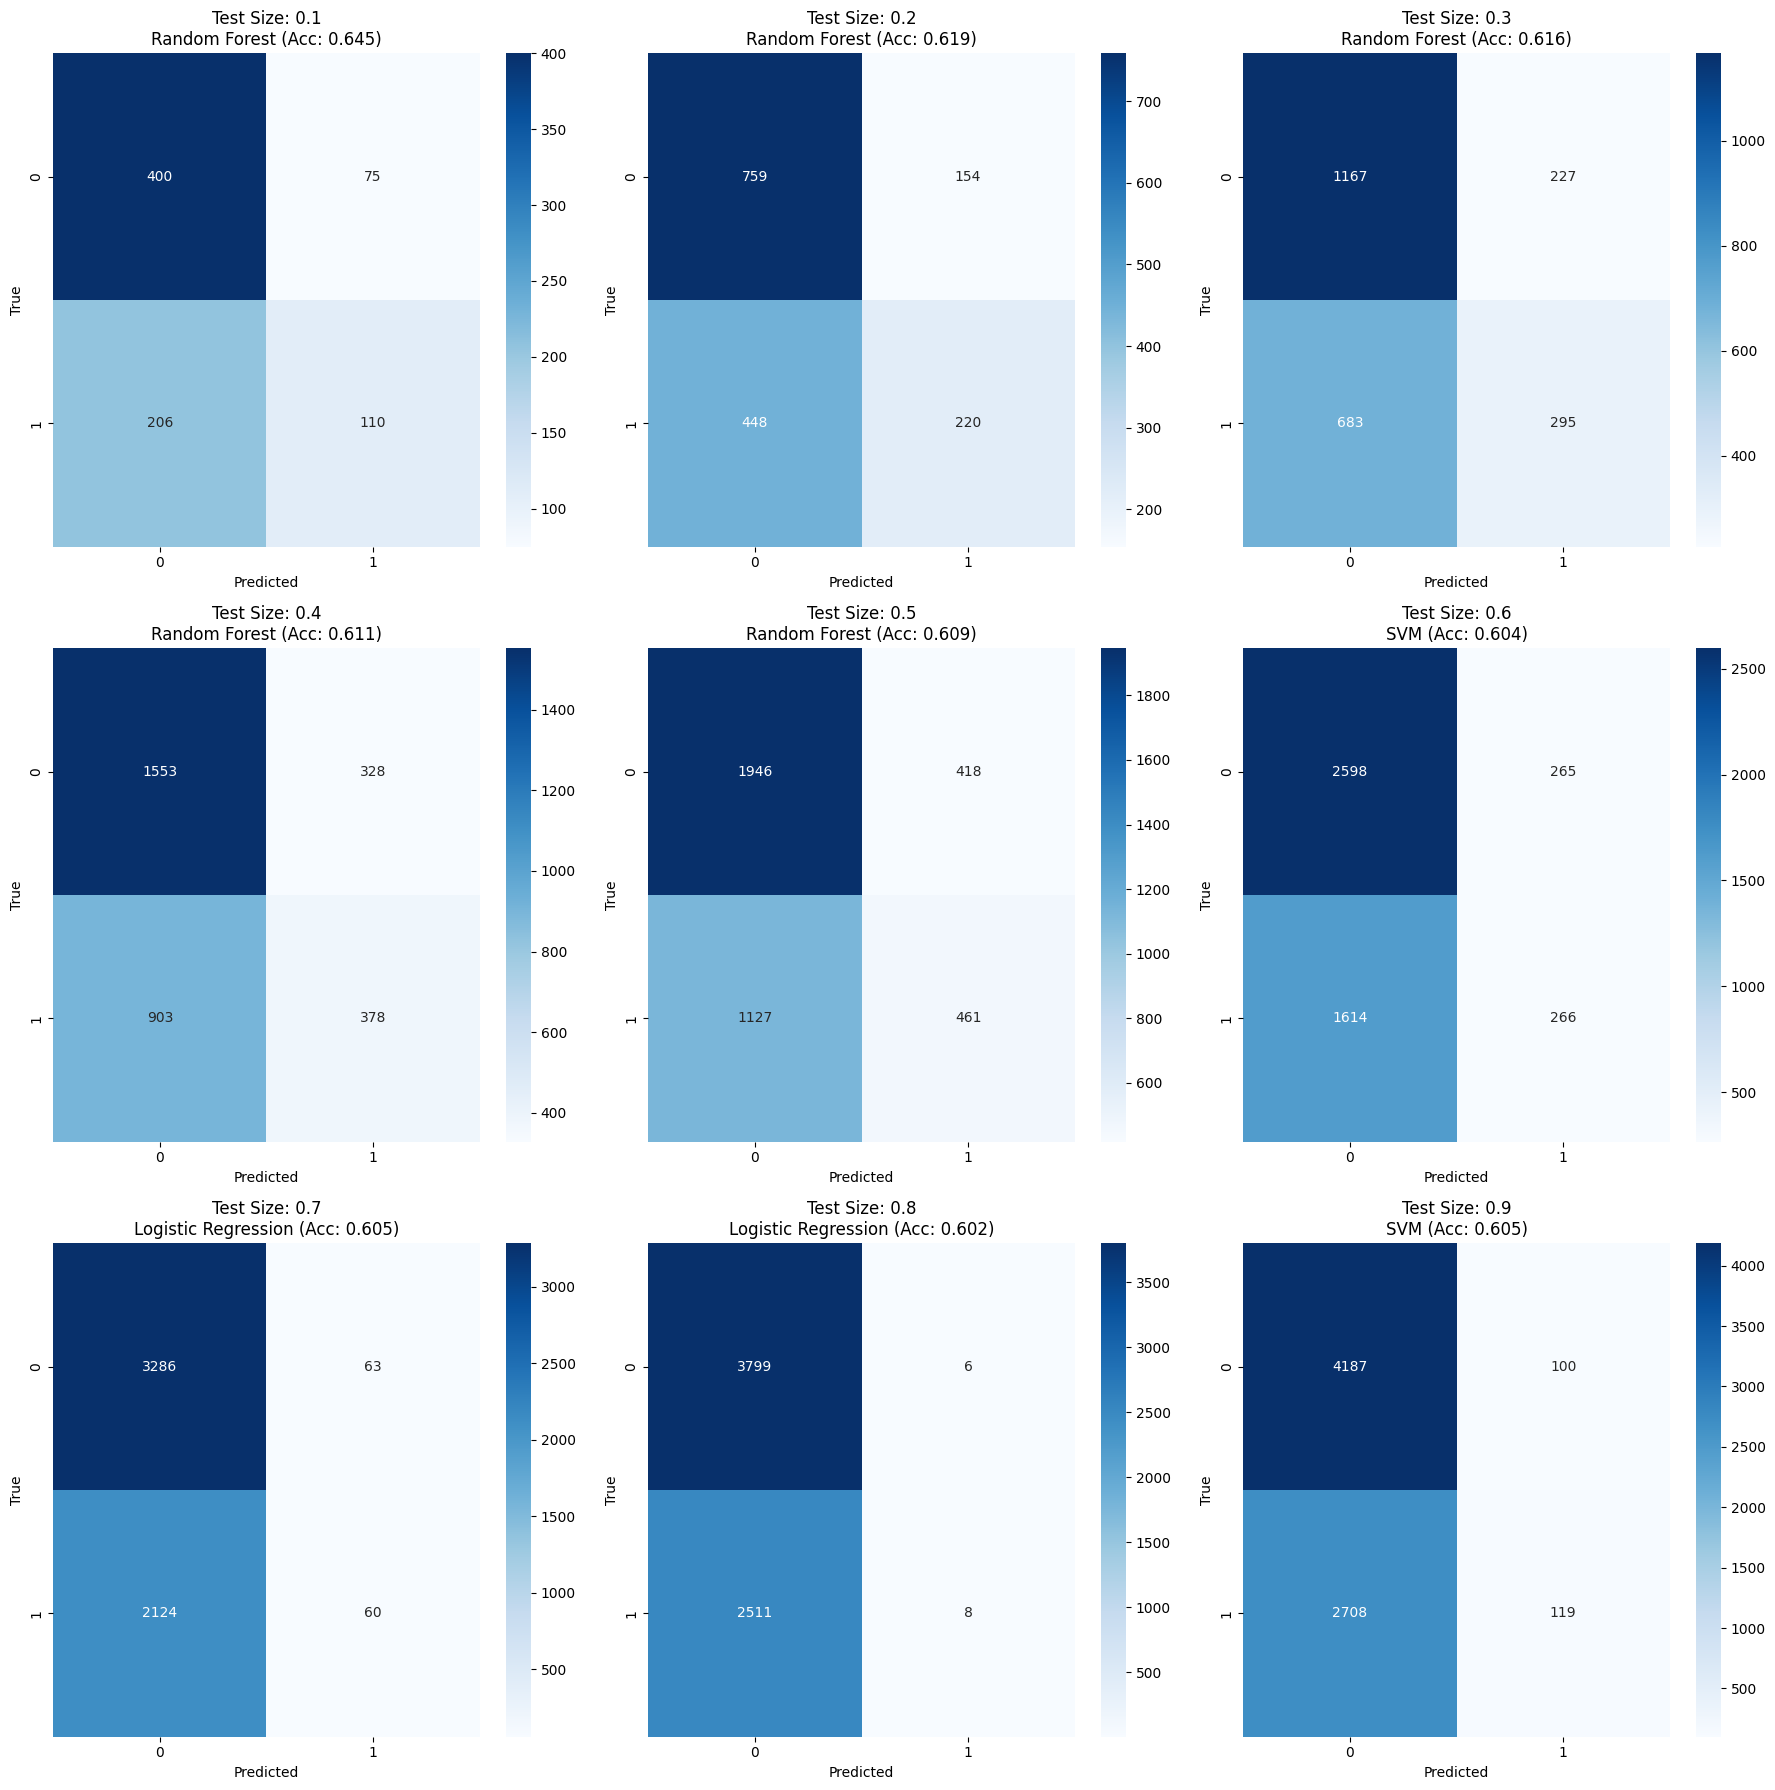

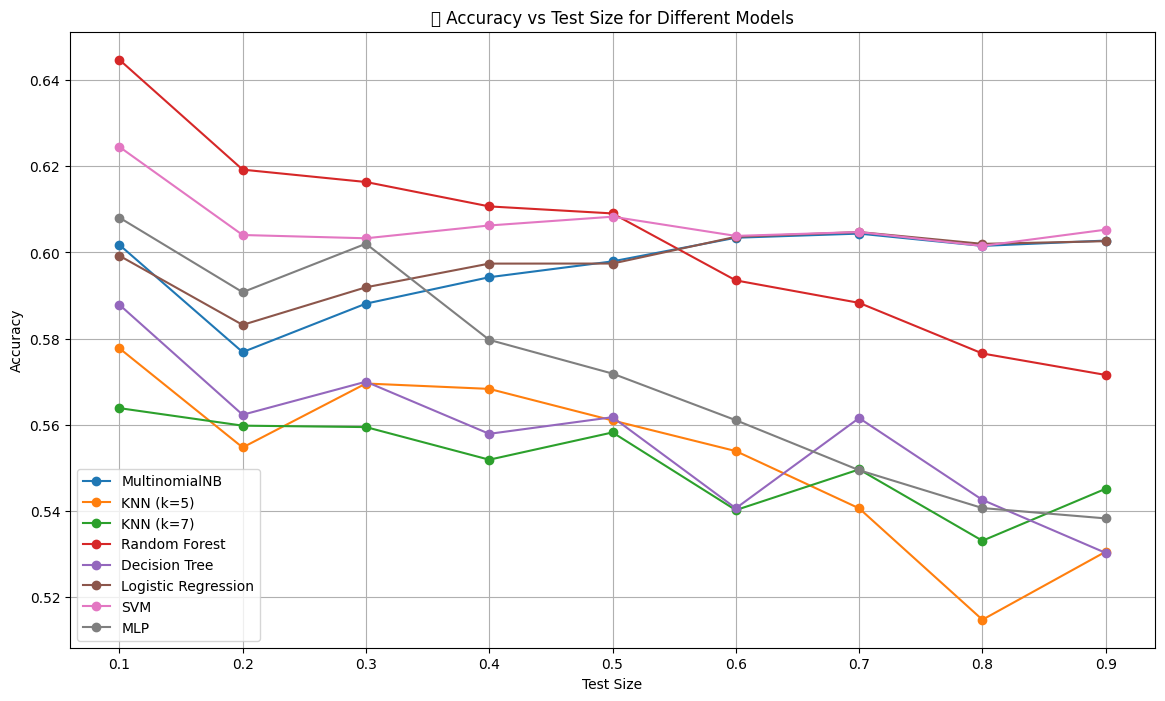

In [ ]:

# 畫出 Confusion Matrix
fig, axs = plt.subplots(3, 3, figsize=(18, 18))
axs = axs.flatten()

for i, (test_size, info) in enumerate(best_model_info.items()):
    cm = info['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axs[i])
    axs[i].set_title(f"Test Size: {test_size:.1f}\n{info['model']} (Acc: {info['accuracy']:.3f})")
    axs[i].set_xlabel("Predicted")
    axs[i].set_ylabel("True")

plt.tight_layout()
plt.show()

# 畫出各模型在不同 test size 下的準確率
plt.figure(figsize=(14, 8))
for name, accs in accuracy_results.items():
    plt.plot(test_sizes, accs, marker='o', label=name)

plt.xlabel("Test Size")
plt.ylabel("Accuracy")
plt.title("📊 Accuracy vs Test Size for Different Models")
plt.legend(loc='lower left')
plt.grid(True)
plt.show()